# FRED Exogenous Feature Analysis

Compare feature correlations across two snapshots:
- **Pre-COVID**: December 2019
- **Latest**: Most recent snapshot

For each data type (VIX, SP500, Credit Spreads, etc.):
1. Side-by-side correlation matrices of all transformations
2. Pairwise correlation tables (sorted by magnitude)
3. Correlation with NFP target (NSA and SA MoM change)

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from settings import DATA_PATH
from utils.transforms import winsorize_covid_period

# Styling
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 1. Load Data

In [78]:
# --- Paths ---
EXOG_DIR = DATA_PATH / "Exogenous_data" / "exogenous_fred_data" / "decades"
TARGET_DIR = DATA_PATH / "NFP_target"

# --- Load pre-COVID snapshot (Dec 2019) ---
pre_covid_path = EXOG_DIR / "2010s" / "2019" / "2019-12.parquet"
snap_pre = pd.read_parquet(pre_covid_path)
snap_pre['date'] = pd.to_datetime(snap_pre['date'])
print(f"Pre-COVID snapshot: {snap_pre['series_name'].nunique()} series, "
      f"{snap_pre['date'].min().date()} to {snap_pre['date'].max().date()}")

# --- Find and load latest snapshot ---
latest_files = sorted(EXOG_DIR.rglob('*.parquet'))
latest_path = latest_files[-1]
snap_latest = pd.read_parquet(latest_path)
snap_latest['date'] = pd.to_datetime(snap_latest['date'])
print(f"Latest snapshot: {latest_path.stem} — {snap_latest['series_name'].nunique()} series, "
      f"{snap_latest['date'].min().date()} to {snap_latest['date'].max().date()}")

# --- Load NFP target data ---
target_nsa = pd.read_parquet(TARGET_DIR / "total_nsa_first_release.parquet")
target_sa  = pd.read_parquet(TARGET_DIR / "total_sa_first_release.parquet")

# Compute MoM difference (these are employment levels, we want changes)
for df in [target_nsa, target_sa]:
    df['ds'] = pd.to_datetime(df['ds'])
    df.sort_values('ds', inplace=True)
    df['y_mom'] = df['y'].diff()

target_nsa = target_nsa.dropna(subset=['y_mom']).set_index('ds')
target_sa  = target_sa.dropna(subset=['y_mom']).set_index('ds')

print(f"\nNSA target: {len(target_nsa)} months ({target_nsa.index.min().date()} to {target_nsa.index.max().date()})")
print(f"SA  target: {len(target_sa)} months ({target_sa.index.min().date()} to {target_sa.index.max().date()})")

Pre-COVID snapshot: 8658 series, 1976-06-01 to 2019-12-01
Latest snapshot: 2026-02 — 8658 series, 1976-06-01 to 2026-02-01

NSA target: 430 months (1990-03-01 to 2025-12-01)
SA  target: 430 months (1990-03-01 to 2025-12-01)


In [79]:
# --- 1b. Drop Short-History Features ---
# Remove any features (series) with fewer than 60 valid (non-NaN) data points
# from BOTH snapshots. These are flagged for manual review.

MIN_VALID_OBS = 60

# Count valid observations per series in each snapshot
valid_counts_latest = snap_latest.groupby('series_name')['value'].count()
valid_counts_pre = snap_pre.groupby('series_name')['value'].count()

# Combined: a feature is "short" if it has < MIN_VALID_OBS in the latest snapshot
short_features = valid_counts_latest[valid_counts_latest < MIN_VALID_OBS].sort_values()

if len(short_features) > 0:
    print(f"⚠ FLAGGED: {len(short_features)} features with < {MIN_VALID_OBS} valid data points (dropped from analysis)")
    print(f"  These are typically rare-event indicators (e.g., circuit breakers) or very new series.\n")
    
    # Display flagged features grouped by prefix
    flagged_df = pd.DataFrame({
        'Series': short_features.index,
        'Valid_Points_Latest': short_features.values,
        'Valid_Points_PreCOVID': [valid_counts_pre.get(s, 0) for s in short_features.index]
    }).reset_index(drop=True)
    
    display(flagged_df.style.background_gradient(
        subset=['Valid_Points_Latest'], cmap='YlOrRd_r', vmin=0, vmax=MIN_VALID_OBS
    ))
    
    # Remove from both snapshots
    drop_set = set(short_features.index)
    snap_latest = snap_latest[~snap_latest['series_name'].isin(drop_set)]
    snap_pre = snap_pre[~snap_pre['series_name'].isin(drop_set)]
    
    print(f"\n✅ Removed {len(drop_set)} short-history features.")
    print(f"   snap_latest: {snap_latest['series_name'].nunique()} series remaining")
    print(f"   snap_pre:    {snap_pre['series_name'].nunique()} series remaining")
else:
    print(f"✅ All features have >= {MIN_VALID_OBS} valid data points. No filtering needed.")

⚠ FLAGGED: 252 features with < 60 valid data points (dropped from analysis)
  These are typically rare-event indicators (e.g., circuit breakers) or very new series.



,Series,Valid_Points_Latest,Valid_Points_PreCOVID
0,SP500_days_circuit_breaker_symlog_pct_chg_zscore_3m_lag_12m,4,4
1,SP500_days_circuit_breaker_symlog_pct_chg_zscore_3m,4,4
2,SP500_days_circuit_breaker_symlog_pct_chg_zscore_3m_lag_18m,4,4
3,SP500_days_circuit_breaker_symlog_pct_chg_zscore_3m_lag_1m,4,4
4,SP500_days_circuit_breaker_symlog_pct_chg_zscore_3m_lag_3m,4,4
5,SP500_days_circuit_breaker_symlog_pct_chg_zscore_3m_lag_6m,4,4
6,SP500_days_circuit_breaker_pct_chg_zscore_3m_lag_6m,4,4
7,SP500_days_circuit_breaker_pct_chg_zscore_3m_lag_1m,4,4
8,SP500_days_circuit_breaker_pct_chg_zscore_3m_lag_3m,4,4
9,SP500_days_circuit_breaker_pct_chg_zscore_3m_lag_12m,4,4



✅ Removed 252 short-history features.
   snap_latest: 8406 series remaining
   snap_pre:    8406 series remaining


## 2. Define Data-Type Groupings

Group the 251+ series by their original data source (VIX, SP500, etc.).

In [80]:
# Data type prefixes — order matters (check longer prefixes first)
DATA_TYPE_PREFIXES = [
    ('VIX_panic_regime',   'VIX (Binary Regimes)'),
    ('VIX_high_regime',    'VIX (Binary Regimes)'),
    ('SP500_bear_market',  'SP500 (Binary Regimes)'),
    ('SP500_crash_month',  'SP500 (Binary Regimes)'),
    ('SP500_circuit_breaker', 'SP500 (Binary Regimes)'),
    ('Credit_Spreads',     'Credit Spreads'),
    ('Yield_Curve',        'Yield Curve'),
    ('Oil_Prices',         'Oil Prices'),
    ('Oil_worst_day',      'Oil Prices'),
    ('VIX',                'VIX'),
    ('SP500',              'SP500'),
    ('CCNSA',              'CCNSA (Continued Claims NSA)'),
    ('CCSA',               'CCSA (Continued Claims SA)'),
    ('Financial_Stress',   'Financial Stress'),
    ('Weekly_Econ_Index',  'Weekly Economic Index'),
]

def classify_series(series_name):
    """Classify a series_name into its data type group."""
    for prefix, group in DATA_TYPE_PREFIXES:
        if series_name.startswith(prefix):
            return group
    return 'Other'

# Get all unique series and classify
all_series = sorted(set(snap_pre['series_name'].unique()) | set(snap_latest['series_name'].unique()))
series_groups = {}
for s in all_series:
    group = classify_series(s)
    series_groups.setdefault(group, []).append(s)

print("Data Type Groups:")
for group, series_list in sorted(series_groups.items()):
    print(f"  {group}: {len(series_list)} series")

Data Type Groups:
  CCNSA (Continued Claims NSA): 504 series
  CCSA (Continued Claims SA): 468 series
  Credit Spreads: 1344 series
  Financial Stress: 576 series
  Oil Prices: 960 series
  SP500: 1644 series
  SP500 (Binary Regimes): 18 series
  VIX: 960 series
  VIX (Binary Regimes): 12 series
  Weekly Economic Index: 576 series
  Yield Curve: 1344 series


## 3. Helper Functions

In [81]:
def pivot_snapshot(snap_df, series_list):
    """
    Pivot a long-format snapshot to wide format for a specific set of series.
    Takes the LATEST value per date per series (most recent observation).
    """
    mask = snap_df['series_name'].isin(series_list)
    subset = snap_df[mask][['date', 'series_name', 'value']].copy()
    
    # Keep latest observation per (date, series_name)
    subset = subset.drop_duplicates(subset=['date', 'series_name'], keep='last')
    
    wide = subset.pivot(index='date', columns='series_name', values='value')
    wide = wide.sort_index()
    
    # Drop columns/rows that are all NaN
    wide = wide.dropna(axis=1, how='all')
    wide = wide.dropna(axis=0, how='all')
    
    return wide


def shorten_name(name, group_name):
    """
    Shorten series name by removing common prefix for display.
    E.g., 'Credit_Spreads_avg_symlog_pct_chg_lag_3m' → 'avg_symlog_pct_chg_lag_3m'
    """
    # Map group names to their base prefixes for stripping
    strip_map = {
        'Credit Spreads': 'Credit_Spreads_',
        'Yield Curve': 'Yield_Curve_',
        'Oil Prices': 'Oil_Prices_',
        'VIX': 'VIX_',
        'SP500': 'SP500_',
        'CCNSA (Continued Claims NSA)': 'CCNSA_',
        'CCSA (Continued Claims SA)': 'CCSA_',
        'Financial Stress': 'Financial_Stress_',
        'Weekly Economic Index': 'Weekly_Econ_Index_',
    }
    prefix = strip_map.get(group_name, '')
    if prefix and name.startswith(prefix):
        return name[len(prefix):]
    return name


def compute_pairwise_correlations(corr_matrix):
    """
    Extract pairwise correlations from a correlation matrix,
    sorted by absolute correlation (descending).
    """
    # Get upper triangle (no diagonal, no duplicates)
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            pairs.append({
                'Feature A': cols[i],
                'Feature B': cols[j],
                'Correlation': corr_matrix.iloc[i, j]
            })
    
    df = pd.DataFrame(pairs)
    df['|Correlation|'] = df['Correlation'].abs()
    df = df.sort_values('|Correlation|', ascending=False).reset_index(drop=True)
    return df


def compute_target_correlations(wide_df, target_series, target_label):
    """
    Compute correlation of each feature with the target MoM change.
    Returns DataFrame sorted by absolute correlation.
    """
    # Align dates
    common_dates = wide_df.index.intersection(target_series.index)
    if len(common_dates) < 10:
        return pd.DataFrame(columns=['Feature', f'Corr with {target_label}', '|Correlation|', 'N'])
    
    target_aligned = target_series.loc[common_dates]
    features_aligned = wide_df.loc[common_dates]
    
    results = []
    for col in features_aligned.columns:
        valid = features_aligned[col].notna() & target_aligned.notna()
        if valid.sum() < 10:
            continue
        corr = features_aligned.loc[valid, col].corr(target_aligned[valid])
        results.append({
            'Feature': col,
            f'Corr with {target_label}': corr,
            '|Correlation|': abs(corr),
            'N': int(valid.sum())
        })
    
    df = pd.DataFrame(results)
    if not df.empty:
        df = df.sort_values('|Correlation|', ascending=False).reset_index(drop=True)
    return df

## 4. Analysis Per Data Type

For each data type, we produce:
1. **Correlation heatmaps** — side-by-side for pre-COVID vs latest
2. **Pairwise correlation tables** — sorted by magnitude
3. **Target correlation tables** — vs NSA MoM and SA MoM for both snapshots

In [82]:
def analyze_data_type(group_name, series_list):
    """
    Run full analysis for one data type group.
    """
    print(f"\n{'='*100}")
    print(f"  {group_name}  ({len(series_list)} series)")
    print(f"{'='*100}")
    
    # Pivot to wide format
    wide_pre = pivot_snapshot(snap_pre, series_list)
    wide_latest = pivot_snapshot(snap_latest, series_list)
    
    # Winsorize COVID period (Mar-May 2020) in latest features
    wide_latest = winsorize_covid_period(wide_latest)
    
    if wide_pre.empty or wide_latest.empty:
        print("  ⚠ Insufficient data for one or both snapshots. Skipping.")
        return
    
    # Shorten column names for display
    short_map_pre = {c: shorten_name(c, group_name) for c in wide_pre.columns}
    short_map_latest = {c: shorten_name(c, group_name) for c in wide_latest.columns}
    wide_pre_short = wide_pre.rename(columns=short_map_pre)
    wide_latest_short = wide_latest.rename(columns=short_map_latest)
    
    # --- PART A: Correlation Matrices (side by side) ---
    print(f"\n--- A. CORRELATION MATRICES ---")
    
    # Only plot heatmap if reasonable number of features (<= 50)
    n_features = max(len(wide_pre_short.columns), len(wide_latest_short.columns))
    
    if n_features <= 50:
        corr_pre = wide_pre_short.corr()
        corr_latest = wide_latest_short.corr()
        
        fig, axes = plt.subplots(1, 2, figsize=(min(24, n_features * 0.6 + 6), 
                                                  min(12, n_features * 0.3 + 3)))
        
        sns.heatmap(corr_pre, ax=axes[0], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                    xticklabels=True, yticklabels=True, square=True,
                    cbar_kws={'shrink': 0.5})
        axes[0].set_title(f'{group_name} — Pre-COVID (Dec 2019)', fontsize=11, fontweight='bold')
        axes[0].tick_params(axis='both', labelsize=6)
        
        sns.heatmap(corr_latest, ax=axes[1], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                    xticklabels=True, yticklabels=True, square=True,
                    cbar_kws={'shrink': 0.5})
        axes[1].set_title(f'{group_name} — Latest ({latest_path.stem}, COVID Winsorized)', fontsize=11, fontweight='bold')
        axes[1].tick_params(axis='both', labelsize=6)
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"  ({n_features} features — heatmap skipped, see pairwise table below)")
    
    # --- PART B: Pairwise Correlations (sorted) ---
    print(f"\n--- B. PAIRWISE CORRELATIONS (top pairs by |correlation|) ---")
    
    corr_pre_full = wide_pre_short.corr()
    corr_latest_full = wide_latest_short.corr()
    
    pairs_pre = compute_pairwise_correlations(corr_pre_full)
    pairs_latest = compute_pairwise_correlations(corr_latest_full)
    
    print(f"\nPre-COVID top 20 pairs:")
    display(pairs_pre.head(20).style.format({'Correlation': '{:.4f}', '|Correlation|': '{:.4f}'}).background_gradient(
        subset=['|Correlation|'], cmap='YlOrRd', vmin=0, vmax=1))
    
    print(f"\nLatest top 20 pairs:")
    display(pairs_latest.head(20).style.format({'Correlation': '{:.4f}', '|Correlation|': '{:.4f}'}).background_gradient(
        subset=['|Correlation|'], cmap='YlOrRd', vmin=0, vmax=1))
    
    # --- PART C: Target Correlations ---
    print(f"\n--- C. TARGET CORRELATIONS (vs NFP MoM Change) ---")
    
    # Pre-COVID snapshot: correlate with targets up to Dec 2019
    target_nsa_pre = target_nsa.loc[target_nsa.index <= '2019-12-01', 'y_mom']
    target_sa_pre  = target_sa.loc[target_sa.index <= '2019-12-01', 'y_mom']
    
    # Latest snapshot: use all available target data (COVID winsorized)
    target_nsa_all = winsorize_covid_period(target_nsa['y_mom'])
    target_sa_all  = winsorize_covid_period(target_sa['y_mom'])
    
    corr_nsa_pre    = compute_target_correlations(wide_pre, target_nsa_pre, 'NSA MoM')
    corr_sa_pre     = compute_target_correlations(wide_pre, target_sa_pre, 'SA MoM')
    corr_nsa_latest = compute_target_correlations(wide_latest, target_nsa_all, 'NSA MoM')
    corr_sa_latest  = compute_target_correlations(wide_latest, target_sa_all, 'SA MoM')
    
    # Shorten feature names for display
    for df_corr in [corr_nsa_pre, corr_sa_pre, corr_nsa_latest, corr_sa_latest]:
        if not df_corr.empty:
            df_corr['Feature'] = df_corr['Feature'].apply(lambda x: shorten_name(x, group_name))
    
    # Build the unified ranking: merge all 4 tables
    print(f"\nTarget correlation tables (sorted by average |correlation| across all 4):")
    
    # Merge all 4 into one wide table for comparison
    all_features = set()
    for df_corr in [corr_nsa_pre, corr_sa_pre, corr_nsa_latest, corr_sa_latest]:
        if not df_corr.empty:
            all_features.update(df_corr['Feature'].tolist())
    
    if not all_features:
        print("  No valid correlations computed.")
        return
    
    merged = pd.DataFrame({'Feature': sorted(all_features)})
    
    for label, df_corr in [
        ('NSA Pre-COVID', corr_nsa_pre),
        ('SA Pre-COVID', corr_sa_pre),
        ('NSA Latest (Winsorized)', corr_nsa_latest),
        ('SA Latest (Winsorized)', corr_sa_latest),
    ]:
        if not df_corr.empty:
            corr_col = [c for c in df_corr.columns if c.startswith('Corr with')][0]
            merge_df = df_corr[['Feature', corr_col]].rename(columns={corr_col: label})
            merged = merged.merge(merge_df, on='Feature', how='left')
    
    # Compute average |correlation| for sorting
    corr_cols = [c for c in merged.columns if c != 'Feature']
    merged['Avg |Corr|'] = merged[corr_cols].abs().mean(axis=1)
    merged = merged.sort_values('Avg |Corr|', ascending=False).reset_index(drop=True)
    
    # Display with color gradient
    display(merged.head(100).style.format(
        {c: '{:.4f}' for c in corr_cols + ['Avg |Corr|']}
    ).background_gradient(
        subset=corr_cols, cmap='RdBu_r', vmin=-0.5, vmax=0.5
    ).background_gradient(
        subset=['Avg |Corr|'], cmap='YlOrRd', vmin=0, vmax=0.5
    ))
    
    return merged


  VIX  (960 series)

--- A. CORRELATION MATRICES ---
  (960 features — heatmap skipped, see pairwise table below)

--- B. PAIRWISE CORRELATIONS (top pairs by |correlation|) ---

Pre-COVID top 20 pairs:


,Feature A,Feature B,Correlation,|Correlation|
0,max_5d_spike_symlog_zscore_3m_lag_18m,max_5d_spike_zscore_3m_lag_18m,0.9999,0.9999
1,max_5d_spike_symlog_zscore_3m_lag_12m,max_5d_spike_zscore_3m_lag_12m,0.9999,0.9999
2,max_5d_spike_symlog_zscore_3m_lag_6m,max_5d_spike_zscore_3m_lag_6m,0.9999,0.9999
3,max_5d_spike_symlog_zscore_3m_lag_3m,max_5d_spike_zscore_3m_lag_3m,0.9999,0.9999
4,max_5d_spike_symlog_zscore_3m_lag_1m,max_5d_spike_zscore_3m_lag_1m,0.9999,0.9999
5,max_5d_spike_symlog_zscore_3m,max_5d_spike_zscore_3m,0.9999,0.9999
6,mean_symlog_zscore_3m_lag_12m,mean_zscore_3m_lag_12m,0.9999,0.9999
7,mean_symlog_zscore_3m_lag_18m,mean_zscore_3m_lag_18m,0.9999,0.9999
8,mean_symlog_zscore_3m_lag_6m,mean_zscore_3m_lag_6m,0.9999,0.9999
9,mean_symlog_zscore_3m_lag_1m,mean_zscore_3m_lag_1m,0.9999,0.9999



Latest top 20 pairs:


,Feature A,Feature B,Correlation,|Correlation|
0,max_5d_spike_symlog_zscore_3m_lag_18m,max_5d_spike_zscore_3m_lag_18m,0.9999,0.9999
1,max_5d_spike_symlog_zscore_3m_lag_6m,max_5d_spike_zscore_3m_lag_6m,0.9999,0.9999
2,max_5d_spike_symlog_zscore_3m_lag_12m,max_5d_spike_zscore_3m_lag_12m,0.9999,0.9999
3,max_5d_spike_symlog_zscore_3m_lag_3m,max_5d_spike_zscore_3m_lag_3m,0.9999,0.9999
4,max_5d_spike_symlog_zscore_3m,max_5d_spike_zscore_3m,0.9999,0.9999
5,max_5d_spike_symlog_zscore_3m_lag_1m,max_5d_spike_zscore_3m_lag_1m,0.9999,0.9999
6,max_5d_spike_pct_chg_zscore_3m_lag_18m,max_5d_spike_symlog_pct_chg_zscore_3m_lag_18m,0.9998,0.9998
7,mean_symlog_zscore_3m,mean_zscore_3m,0.9998,0.9998
8,mean_symlog_zscore_3m_lag_18m,mean_zscore_3m_lag_18m,0.9998,0.9998
9,mean_symlog_zscore_3m_lag_3m,mean_zscore_3m_lag_3m,0.9998,0.9998



--- C. TARGET CORRELATIONS (vs NFP MoM Change) ---

Target correlation tables (sorted by average |correlation| across all 4):


...


Latest top 20 pairs:


,Feature A,Feature B,Correlation,|Correlation|
0,monthly_avg_symlog_zscore_3m,monthly_avg_zscore_3m,0.9997,0.9997
1,monthly_max_symlog_zscore_3m,monthly_max_zscore_3m,0.9997,0.9997
2,monthly_avg_symlog_zscore_3m_lag_1m,monthly_avg_zscore_3m_lag_1m,0.9997,0.9997
3,monthly_max_symlog_zscore_3m_lag_1m,monthly_max_zscore_3m_lag_1m,0.9997,0.9997
4,monthly_max_symlog_zscore_3m_lag_3m,monthly_max_zscore_3m_lag_3m,0.9997,0.9997
5,monthly_avg_symlog_zscore_3m_lag_3m,monthly_avg_zscore_3m_lag_3m,0.9997,0.9997
6,monthly_max_symlog_zscore_3m_lag_6m,monthly_max_zscore_3m_lag_6m,0.9997,0.9997
7,monthly_avg_symlog_zscore_3m_lag_6m,monthly_avg_zscore_3m_lag_6m,0.9997,0.9997
8,monthly_max_symlog_zscore_3m_lag_12m,monthly_max_zscore_3m_lag_12m,0.9997,0.9997
9,monthly_max_symlog_zscore_3m_lag_18m,monthly_max_zscore_3m_lag_18m,0.9997,0.9997



--- C. TARGET CORRELATIONS (vs NFP MoM Change) ---

Target correlation tables (sorted by average |correlation| across all 4):


,Feature,NSA Pre-COVID,SA Pre-COVID,NSA Latest (Winsorized),SA Latest (Winsorized),Avg |Corr|
0,monthly_avg_rolling_std_6m_lag_1m,-0.1657,-0.5060,0.1629,0.4538,0.3221
1,monthly_max_rolling_std_6m_lag_1m,-0.1754,-0.4820,0.1553,0.4361,0.3122
2,monthly_avg_pct_chg_rolling_std_6m,-0.1888,-0.6496,0.1110,0.2758,0.3063
3,monthly_max_symlog_rolling_std_6m_lag_1m,-0.2113,-0.5613,0.1000,0.3521,0.3062
4,monthly_min_rolling_std_6m_lag_1m,-0.1653,-0.4816,0.1361,0.4400,0.3058
5,monthly_avg_rolling_std_6m,-0.1810,-0.5226,0.1118,0.3796,0.2987
6,monthly_max_rolling_std_6m,-0.1870,-0.4891,0.1235,0.3943,0.2985
7,monthly_avg_pct_chg_rolling_std_6m_lag_1m,-0.1693,-0.6274,0.1333,0.2621,0.2980
8,monthly_avg_symlog_rolling_std_6m_lag_1m,-0.1978,-0.5497,0.0910,0.3440,0.2956
9,monthly_max_symlog_rolling_std_6m,-0.2386,-0.5840,0.0304,0.2893,0.2856



  VIX (Binary Regimes)  (12 series)

--- A. CORRELATION MATRICES ---


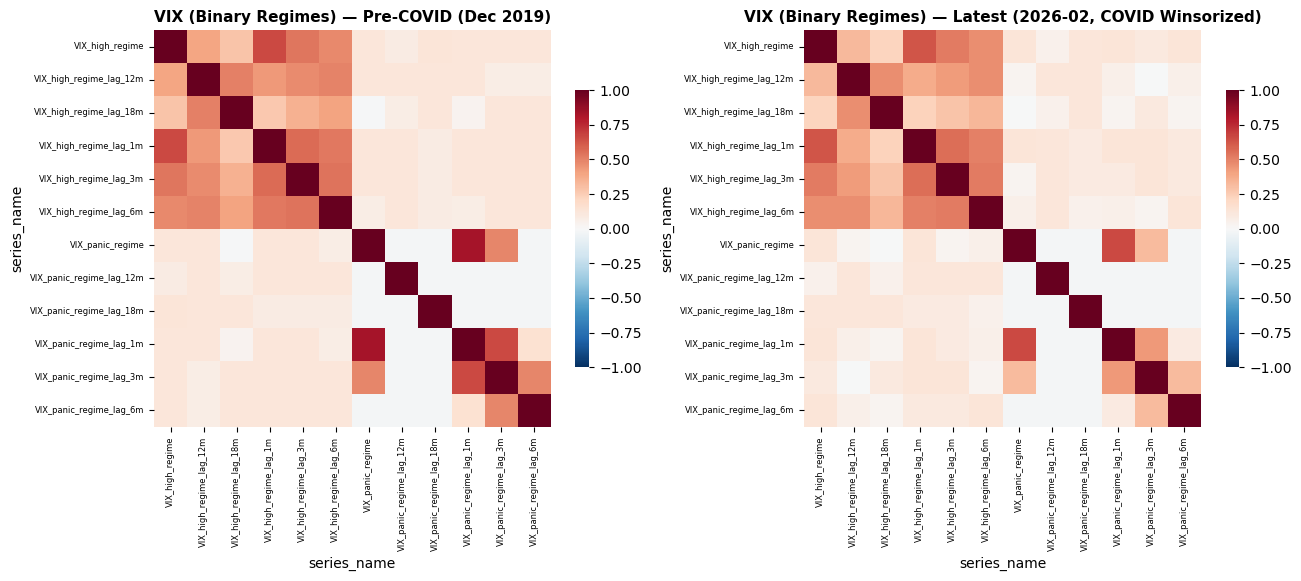


--- B. PAIRWISE CORRELATIONS (top pairs by |correlation|) ---

Pre-COVID top 20 pairs:


,Feature A,Feature B,Correlation,|Correlation|
0,VIX_panic_regime,VIX_panic_regime_lag_1m,0.8305,0.8305
1,VIX_panic_regime_lag_1m,VIX_panic_regime_lag_3m,0.6610,0.6610
2,VIX_high_regime,VIX_high_regime_lag_1m,0.6578,0.6578
3,VIX_high_regime_lag_1m,VIX_high_regime_lag_3m,0.5656,0.5656
4,VIX_high_regime_lag_3m,VIX_high_regime_lag_6m,0.5448,0.5448
5,VIX_high_regime,VIX_high_regime_lag_3m,0.5376,0.5376
6,VIX_high_regime_lag_1m,VIX_high_regime_lag_6m,0.5280,0.5280
7,VIX_high_regime_lag_12m,VIX_high_regime_lag_18m,0.5045,0.5045
8,VIX_high_regime_lag_12m,VIX_high_regime_lag_6m,0.4961,0.4961
9,VIX_panic_regime,VIX_panic_regime_lag_3m,0.4915,0.4915



Latest top 20 pairs:


,Feature A,Feature B,Correlation,|Correlation|
0,VIX_panic_regime,VIX_panic_regime_lag_1m,0.6596,0.6596
1,VIX_high_regime,VIX_high_regime_lag_1m,0.6319,0.6319
2,VIX_high_regime_lag_1m,VIX_high_regime_lag_3m,0.5593,0.5593
3,VIX_high_regime,VIX_high_regime_lag_3m,0.5214,0.5214
4,VIX_high_regime_lag_3m,VIX_high_regime_lag_6m,0.5183,0.5183
5,VIX_high_regime_lag_1m,VIX_high_regime_lag_6m,0.5043,0.5043
6,VIX_high_regime_lag_12m,VIX_high_regime_lag_6m,0.4686,0.4686
7,VIX_high_regime_lag_12m,VIX_high_regime_lag_18m,0.4621,0.4621
8,VIX_high_regime,VIX_high_regime_lag_6m,0.4610,0.4610
9,VIX_panic_regime_lag_1m,VIX_panic_regime_lag_3m,0.4326,0.4326



--- C. TARGET CORRELATIONS (vs NFP MoM Change) ---

Target correlation tables (sorted by average |correlation| across all 4):


,Feature,NSA Pre-COVID,SA Pre-COVID,NSA Latest (Winsorized),SA Latest (Winsorized),Avg |Corr|
0,VIX_panic_regime,-0.1279,-0.4308,-0.1393,-0.3070,0.2513
1,VIX_panic_regime_lag_1m,-0.1270,-0.4468,-0.1165,-0.2355,0.2315
2,VIX_panic_regime_lag_3m,-0.0884,-0.3878,-0.0062,0.0544,0.1342
3,VIX_high_regime_lag_6m,-0.0610,-0.2889,-0.0242,-0.1539,0.1320
4,VIX_high_regime_lag_12m,-0.0681,-0.2463,-0.0297,-0.1094,0.1134
5,VIX_high_regime_lag_3m,-0.0920,-0.2574,-0.0551,-0.0450,0.1124
6,VIX_high_regime_lag_1m,-0.0885,-0.2340,-0.0459,-0.0513,0.1049
7,VIX_high_regime,-0.0794,-0.2688,-0.0071,-0.0513,0.1017
8,VIX_panic_regime_lag_6m,-0.0309,-0.2392,0.0207,-0.0954,0.0965
9,VIX_panic_regime_lag_12m,-0.0652,-0.1673,-0.0184,-0.0578,0.0772



  SP500 (Binary Regimes)  (18 series)

--- A. CORRELATION MATRICES ---


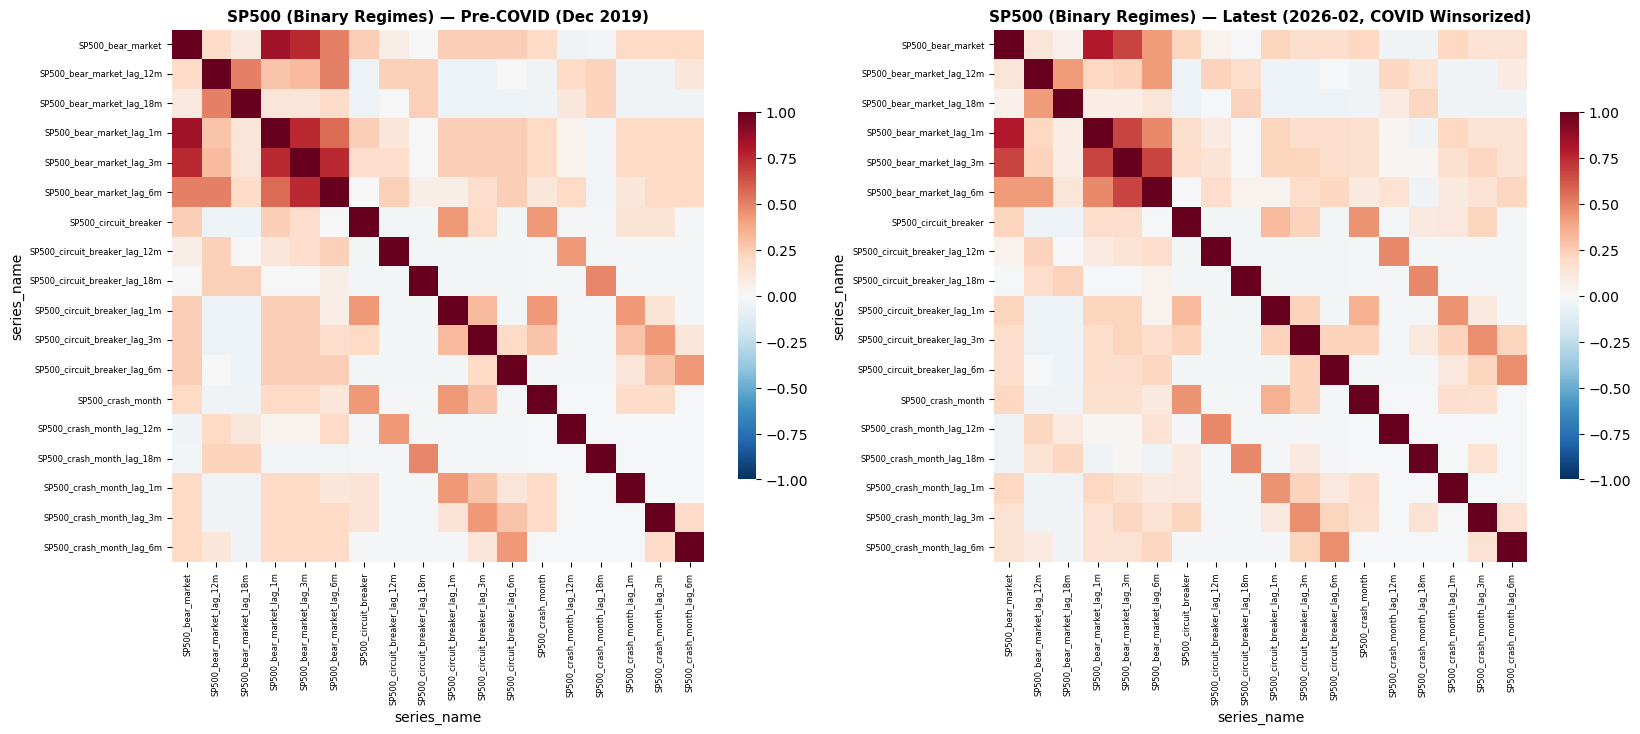


--- B. PAIRWISE CORRELATIONS (top pairs by |correlation|) ---

Pre-COVID top 20 pairs:


,Feature A,Feature B,Correlation,|Correlation|
0,SP500_bear_market,SP500_bear_market_lag_1m,0.8456,0.8456
1,SP500_bear_market_lag_1m,SP500_bear_market_lag_3m,0.7529,0.7529
2,SP500_bear_market,SP500_bear_market_lag_3m,0.7529,0.7529
3,SP500_bear_market_lag_3m,SP500_bear_market_lag_6m,0.7526,0.7526
4,SP500_bear_market_lag_1m,SP500_bear_market_lag_6m,0.5671,0.5671
5,SP500_bear_market,SP500_bear_market_lag_6m,0.5052,0.5052
6,SP500_bear_market_lag_12m,SP500_bear_market_lag_6m,0.5043,0.5043
7,SP500_bear_market_lag_12m,SP500_bear_market_lag_18m,0.5033,0.5033
8,SP500_circuit_breaker_lag_18m,SP500_crash_month_lag_18m,0.4918,0.4918
9,SP500_circuit_breaker,SP500_crash_month,0.4371,0.4371



Latest top 20 pairs:


,Feature A,Feature B,Correlation,|Correlation|
0,SP500_bear_market,SP500_bear_market_lag_1m,0.8016,0.8016
1,SP500_bear_market,SP500_bear_market_lag_3m,0.6774,0.6774
2,SP500_bear_market_lag_1m,SP500_bear_market_lag_3m,0.6774,0.6774
3,SP500_bear_market_lag_3m,SP500_bear_market_lag_6m,0.6772,0.6772
4,SP500_circuit_breaker_lag_12m,SP500_crash_month_lag_12m,0.4828,0.4828
5,SP500_circuit_breaker_lag_18m,SP500_crash_month_lag_18m,0.4827,0.4827
6,SP500_bear_market_lag_1m,SP500_bear_market_lag_6m,0.4785,0.4785
7,SP500_circuit_breaker_lag_3m,SP500_crash_month_lag_3m,0.4614,0.4614
8,SP500_circuit_breaker_lag_6m,SP500_crash_month_lag_6m,0.4613,0.4613
9,SP500_circuit_breaker_lag_1m,SP500_crash_month_lag_1m,0.4463,0.4463



--- C. TARGET CORRELATIONS (vs NFP MoM Change) ---

Target correlation tables (sorted by average |correlation| across all 4):


,Feature,NSA Pre-COVID,SA Pre-COVID,NSA Latest (Winsorized),SA Latest (Winsorized),Avg |Corr|
0,SP500_bear_market,-0.1049,-0.4894,-0.1181,-0.2956,0.2520
1,SP500_bear_market_lag_1m,-0.0900,-0.4804,-0.0949,-0.2537,0.2298
2,SP500_bear_market_lag_6m,-0.1067,-0.4183,-0.0812,-0.2111,0.2043
3,SP500_bear_market_lag_3m,-0.1193,-0.4676,-0.0564,-0.1286,0.1930
4,SP500_crash_month_lag_1m,-0.0828,-0.2361,-0.1168,-0.1853,0.1552
5,SP500_circuit_breaker_lag_1m,-0.0633,-0.2610,-0.0829,-0.1305,0.1344
6,SP500_crash_month,-0.0971,-0.1882,-0.0885,-0.1567,0.1326
7,SP500_circuit_breaker_lag_3m,-0.1519,-0.2718,-0.0580,0.0304,0.1280
8,SP500_crash_month_lag_3m,-0.0606,-0.1794,0.0395,0.1389,0.1046
9,SP500_crash_month_lag_18m,0.0009,-0.0137,0.1019,0.2487,0.0913


In [83]:
# Run analysis for all data types (excluding binary regimes which only have 1 feature each)
all_target_results = {}

analysis_order = [
    'VIX',
    'SP500',
    'Credit Spreads',
    'Yield Curve',
    'Oil Prices',
    'CCSA (Continued Claims SA)',
    'CCNSA (Continued Claims NSA)',
    'Financial Stress',
    'Weekly Economic Index',
    'VIX (Binary Regimes)',
    'SP500 (Binary Regimes)',
]

for group_name in analysis_order:
    if group_name in series_groups:
        result = analyze_data_type(group_name, series_groups[group_name])
        if result is not None:
            all_target_results[group_name] = result

## 5. Cross-Group Summary: Top Features by Target Correlation

In [84]:
# Combine all target correlation results across groups
all_combined = []
for group_name, df in all_target_results.items():
    df_copy = df.copy()
    df_copy['Data Type'] = group_name
    all_combined.append(df_copy)

if all_combined:
    combined = pd.concat(all_combined, ignore_index=True)
    combined = combined.sort_values('Avg |Corr|', ascending=False).reset_index(drop=True)
    
    print("=" * 100)
    print("  TOP 50 FEATURES BY TARGET CORRELATION (across all data types)")
    print("=" * 100)
    
    corr_cols = [c for c in combined.columns if c not in ['Feature', 'Data Type', 'Avg |Corr|']]
    
    display(
        combined.head(50)[['Data Type', 'Feature'] + corr_cols + ['Avg |Corr|']].style.format(
            {c: '{:.4f}' for c in corr_cols + ['Avg |Corr|']}
        ).background_gradient(
            subset=corr_cols, cmap='RdBu_r', vmin=-0.5, vmax=0.5
        ).background_gradient(
            subset=['Avg |Corr|'], cmap='YlOrRd', vmin=0, vmax=0.5
        )
    )
else:
    print("No results to combine.")

  TOP 50 FEATURES BY TARGET CORRELATION (across all data types)


,Data Type,Feature,NSA Pre-COVID,SA Pre-COVID,NSA Latest (Winsorized),SA Latest (Winsorized),Avg |Corr|
0,CCNSA (Continued Claims NSA),monthly_avg_diff,-0.7795,-0.1780,-0.6067,-0.3955,0.4899
1,CCNSA (Continued Claims NSA),max_spike_diff,-0.7017,-0.1615,-0.5789,-0.4501,0.4730
2,CCNSA (Continued Claims NSA),monthly_avg_pct_chg,-0.7545,-0.1190,-0.7218,-0.1650,0.4401
3,CCNSA (Continued Claims NSA),monthly_avg_symlog_diff,-0.7504,-0.1221,-0.7134,-0.1728,0.4397
4,CCNSA (Continued Claims NSA),monthly_avg_symlog_pct_chg,-0.7466,-0.1184,-0.7116,-0.1627,0.4348
5,CCNSA (Continued Claims NSA),max_spike_pct_chg,-0.6930,-0.1227,-0.6642,-0.1938,0.4184
6,CCNSA (Continued Claims NSA),max_spike_symlog_diff,-0.6860,-0.1220,-0.6547,-0.1959,0.4147
7,CCNSA (Continued Claims NSA),max_spike_symlog_pct_chg,-0.6836,-0.1195,-0.6527,-0.1856,0.4103
8,CCNSA (Continued Claims NSA),monthly_avg_diff_zscore_12m,-0.7819,-0.0415,-0.7348,-0.0578,0.4040
9,CCNSA (Continued Claims NSA),max_spike_zscore_3m,-0.6767,-0.1030,-0.6571,-0.1509,0.3969


## 6. Stability Analysis: Pre-COVID vs Latest Correlation Shift

In [85]:
# For features that appear in both snapshots, compare how their target correlations changed
if all_combined:
    stability = combined.copy()
    
    nsa_pre_col = [c for c in stability.columns if 'NSA Pre' in c]
    nsa_latest_col = [c for c in stability.columns if 'NSA Latest' in c]
    sa_pre_col = [c for c in stability.columns if 'SA Pre' in c]
    sa_latest_col = [c for c in stability.columns if 'SA Latest' in c]
    
    if nsa_pre_col and nsa_latest_col:
        stability['NSA Shift'] = stability[nsa_latest_col[0]] - stability[nsa_pre_col[0]]
    if sa_pre_col and sa_latest_col:
        stability['SA Shift'] = stability[sa_latest_col[0]] - stability[sa_pre_col[0]]
    
    shift_cols = [c for c in ['NSA Shift', 'SA Shift'] if c in stability.columns]
    
    if shift_cols:
        # Features whose correlation changed the most
        stability['Max |Shift|'] = stability[shift_cols].abs().max(axis=1)
        stability = stability.sort_values('Max |Shift|', ascending=False)
        
        print("=" * 100)
        print("  LARGEST CORRELATION SHIFTS (Pre-COVID → Latest)")
        print("  Features where correlation with NFP target changed most")
        print("=" * 100)
        
        display_cols = ['Data Type', 'Feature'] + shift_cols + ['Max |Shift|', 'Avg |Corr|']
        display(
            stability.head(30)[display_cols].style.format(
                {c: '{:+.4f}' for c in shift_cols} | {'Max |Shift|': '{:.4f}', 'Avg |Corr|': '{:.4f}'}
            ).background_gradient(
                subset=shift_cols, cmap='RdBu_r', vmin=-0.3, vmax=0.3
            )
        )

  LARGEST CORRELATION SHIFTS (Pre-COVID → Latest)
  Features where correlation with NFP target changed most


,Data Type,Feature,NSA Shift,SA Shift,Max |Shift|,Avg |Corr|
143,CCNSA (Continued Claims NSA),monthly_avg_pct_chg_lag_12m,+0.5409,+0.5409,0.5409,0.2645
113,CCNSA (Continued Claims NSA),monthly_avg_diff_lag_12m,+0.5353,+0.5353,0.5353,0.2800
180,CCNSA (Continued Claims NSA),max_spike_diff_lag_12m,+0.5124,+0.5124,0.5124,0.2531
181,CCNSA (Continued Claims NSA),max_spike_pct_chg_lag_12m,+0.4985,+0.4985,0.4985,0.2527
133,CCNSA (Continued Claims NSA),max_spike_chg_3m,+0.3918,+0.3918,0.3918,0.2678
731,CCNSA (Continued Claims NSA),max_spike_chg_3m_lag_12m,+0.3896,+0.3896,0.3896,0.1789
120,CCNSA (Continued Claims NSA),monthly_avg_chg_3m,+0.3852,+0.3852,0.3852,0.2750
60,CCNSA (Continued Claims NSA),monthly_avg_pct_chg_rolling_mean_3m,+0.3833,+0.3833,0.3833,0.3052
602,CCNSA (Continued Claims NSA),max_spike_pct_chg_rolling_mean_3m_lag_12m,+0.3792,+0.3792,0.3792,0.1927
51,CCNSA (Continued Claims NSA),max_spike_pct_chg_rolling_mean_3m,+0.3724,+0.3724,0.3724,0.3113


In [86]:
# --- 6. Feature Selection with VIF (Per Group) ---
# Features with < 60 valid points were already removed in cell 1b.
# Now: top 100 correlated -> align to common window -> iterative VIF reduction.
# PRIORITY: Maintain features most correlated with SA WINSORIZED TARGET.

from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm.notebook import tqdm

def select_features_vif(X, y, group_name, threshold=10, top_k=100):
    """
    Select features via iterative VIF reduction.
    Prioritizes keeping features with higher correlation to 'y' (SA Target).
    
    Steps:
    1. Pick top_k features by |correlation| with y (pairwise, NaN-safe)
    2. Align to common non-NaN window (dropna on rows)
    3. Iteratively drop the feature in the highest-VIF pair that has lower |corr| with y
    4. Constraint: keep at least one feature with |corr| > 0.3 if any exist
    """
    # 1. Pairwise correlations with SA Target
    corrs = X.corrwith(y).abs().sort_values(ascending=False)
    
    # Identify Champion (highest corr feature) for constraint
    champion_feature = corrs.index[0] if not corrs.empty else None
    features_above_03 = set(corrs[corrs > 0.3].index)
    has_high_corr = len(features_above_03) > 0
    
    top_features = corrs.head(top_k).index.tolist()
    X_curr = X[top_features].copy()
    
    # 2. Align to common valid window
    common_idx = X_curr.dropna().index.intersection(y.dropna().index)
    X_curr = X_curr.loc[common_idx]
    y_curr = y.loc[common_idx]
    
    if len(X_curr) < 20:
        print(f"  Skipping {group_name}: too few rows ({len(X_curr)}) for stable VIF.")
        return []
        
    if len(X_curr) < 100:
        print(f"  Note: {group_name} has {len(X_curr)} common valid rows after alignment.")
    
    # 3. Iterative VIF reduction
    iteration = 0
    while X_curr.shape[1] > 1:
        try:
            vifs = [variance_inflation_factor(X_curr.values, i) for i in range(X_curr.shape[1])]
        except Exception as e:
            print(f"  VIF Error: {e}. Stopping.")
            break
        
        max_vif = max(vifs)
        if max_vif <= threshold:
            break
        
        max_idx = vifs.index(max_vif)
        feature_max = X_curr.columns[max_idx]
        
        # Find most correlated partner
        curr_corr = X_curr.corr().abs()
        collinear_partner = curr_corr[feature_max].drop(feature_max).idxmax()
        
        # Compare correlations with SA TARGET
        corr_max = abs(X_curr[feature_max].corr(y_curr))
        corr_partner = abs(X_curr[collinear_partner].corr(y_curr))
        
        if corr_max < corr_partner:
            drop_cand, keep_cand = feature_max, collinear_partner
        else:
            drop_cand, keep_cand = collinear_partner, feature_max
        
        # 4. Constraint: preserve Champion if it's high-quality (>0.3)
        if has_high_corr and drop_cand == champion_feature and corr_max > 0.3:
            # Our drop candidate is the group champion! Try dropping the partner instead.
            drop_cand = keep_cand
            # If partner is somehow also critical (unlikely in intra-group), we might still drop it
        
        # If we switched drop_cand, ensure we aren't emptying the high-corr set entirely
        if has_high_corr and drop_cand in features_above_03:
            remaining_high = [f for f in X_curr.columns if f in features_above_03 and f != drop_cand]
            if not remaining_high:
                # Can't drop the last good feature. 
                # If we were trying to save the champion, and now can't drop partner... stuck.
                # Just stop here.
                break
        
        X_curr = X_curr.drop(columns=[drop_cand])
        iteration += 1
    
    return X_curr.columns.tolist()


# --- Prepare Data ---
print("Preparing data for VIF Analysis...")
if 'value' in snap_latest.columns:
    df_pivot = snap_latest.pivot(index='date', columns='series_name', values='value').sort_index()
else:
    df_pivot = snap_latest.copy()

# Winsorize COVID period in features
df_pivot = winsorize_covid_period(df_pivot)

# Align with SA Target (Winsorized) - THE PRIORITY TARGET
y_sa_all = winsorize_covid_period(target_sa['y_mom'])
y_nsa_all = winsorize_covid_period(target_nsa['y_mom'])

common_dates = df_pivot.index.intersection(y_sa_all.index)
df_pivot = df_pivot.loc[common_dates]
y_target = y_sa_all.loc[common_dates]
y_target_nsa = y_nsa_all.loc[common_dates.intersection(y_nsa_all.index)]

# --- Run Per-Group Selection ---
selected_features_all = {}
final_stats = []

for group_name, series_list in tqdm(sorted(series_groups.items()), desc="VIF Selection"):
    available_series = [s for s in series_list if s in df_pivot.columns]
    
    if len(available_series) < 2:
        continue
    
    X_group = df_pivot[available_series]
    
    try:
        selected_names = select_features_vif(X_group, y_target, group_name)
        if not selected_names:
            continue
            
        selected_features_all[group_name] = selected_names
        
        for feat in selected_names:
            corr_sa = X_group[feat].corr(y_target)
            common_nsa = X_group.index.intersection(y_target_nsa.index)
            corr_nsa = X_group.loc[common_nsa, feat].corr(y_target_nsa.loc[common_nsa]) if not common_nsa.empty else float('nan')
            
            final_stats.append({
                'Group': group_name,
                'Feature': feat,
                'Corr_SA_Winsorized': corr_sa,
                'Corr_NSA_Winsorized': corr_nsa,
                'Abs_Corr_SA': abs(corr_sa)
            })
    except Exception as e:
        print(f"Error processing {group_name}: {e}")

# --- Display Per-Group Results ---
if final_stats:
    df_results = pd.DataFrame(final_stats)
    df_results = df_results.sort_values(['Group', 'Abs_Corr_SA'], ascending=[True, False])
    
    total_selected = len(df_results)
    print(f"\n{'='*80}")
    print(f"  VIF SELECTION RESULTS: {total_selected} features across {len(selected_features_all)} groups")
    print(f"{'='*80}")
    
    for group_name in sorted(df_results['Group'].unique()):
        subset = df_results[df_results['Group'] == group_name][['Feature', 'Corr_SA_Winsorized', 'Corr_NSA_Winsorized']].reset_index(drop=True)
        print(f"\n--- {group_name} ({len(subset)} features) ---")
        display(subset.head(100).style.format({
            'Corr_SA_Winsorized': '{:.4f}',
            'Corr_NSA_Winsorized': '{:.4f}'
        }).background_gradient(cmap='coolwarm', axis=0, subset=['Corr_SA_Winsorized', 'Corr_NSA_Winsorized']))
else:
    print("No features selected.")

Preparing data for VIF Analysis...


VIF Selection:   0%|          | 0/11 [00:00<?, ?it/s]


  VIF SELECTION RESULTS: 206 features across 11 groups

--- CCNSA (Continued Claims NSA) (13 features) ---


,Feature,Corr_SA_Winsorized,Corr_NSA_Winsorized
0,CCNSA_monthly_avg,0.3132,0.0110
1,CCNSA_max_spike_symlog_rolling_std_6m_lag_3m,0.2903,0.2205
2,CCNSA_monthly_avg_chg_12m_lag_1m,0.2054,0.0655
3,CCNSA_max_spike_symlog_diff,-0.1959,-0.6547
4,CCNSA_monthly_avg_pct_chg_lag_3m,0.1805,0.1465
5,CCNSA_monthly_avg_rolling_std_6m_lag_12m,0.1785,0.0492
6,CCNSA_max_spike_diff_lag_1m,-0.1558,-0.2653
7,CCNSA_max_spike_symlog_zscore_3m,-0.1518,-0.6538
8,CCNSA_max_spike_symlog_chg_6m,0.1478,-0.0191
9,CCNSA_weeks_high_symlog_zscore_12m_lag_6m,-0.1376,-0.1540



--- CCSA (Continued Claims SA) (17 features) ---


...

,Feature,Corr_SA_Winsorized,Corr_NSA_Winsorized
0,VIX_panic_regime,-0.3070,-0.1393
1,VIX_panic_regime_lag_1m,-0.2355,-0.1165
2,VIX_high_regime_lag_6m,-0.1539,-0.0242
3,VIX_high_regime_lag_12m,-0.1094,-0.0297
4,VIX_panic_regime_lag_6m,-0.0954,0.0207
5,VIX_panic_regime_lag_12m,-0.0578,-0.0184
6,VIX_panic_regime_lag_3m,0.0544,-0.0062
7,VIX_high_regime_lag_18m,-0.0522,-0.0053
8,VIX_high_regime,-0.0513,-0.0071
9,VIX_high_regime_lag_1m,-0.0513,-0.0459



--- Weekly Economic Index (26 features) ---


,Feature,Corr_SA_Winsorized,Corr_NSA_Winsorized
0,Weekly_Econ_Index_monthly_avg_rolling_std_6m_lag_1m,0.4538,0.1629
1,Weekly_Econ_Index_monthly_min_symlog_diff_lag_3m,-0.3332,-0.1713
2,Weekly_Econ_Index_monthly_max_symlog_chg_3m_lag_1m,-0.2896,-0.1424
3,Weekly_Econ_Index_monthly_max_diff,0.2508,0.2383
4,Weekly_Econ_Index_monthly_max_symlog_chg_6m_lag_1m,-0.2049,-0.1058
5,Weekly_Econ_Index_monthly_avg_pct_chg_rolling_std_6m_lag_3m,0.1883,0.1064
6,Weekly_Econ_Index_monthly_min_symlog_pct_chg_rolling_std_6m,0.1583,0.0852
7,Weekly_Econ_Index_monthly_max_lag_6m,0.1499,0.0811
8,Weekly_Econ_Index_monthly_avg_symlog_diff_zscore_12m_lag_3m,-0.1447,-0.0815
9,Weekly_Econ_Index_monthly_avg_pct_chg,-0.1363,-0.0763



--- Yield Curve (15 features) ---


,Feature,Corr_SA_Winsorized,Corr_NSA_Winsorized
0,Yield_Curve_zscore_max,-0.2764,-0.0828
1,Yield_Curve_monthly_chg_rolling_std_6m,-0.2633,-0.0918
2,Yield_Curve_avg_chg_12m,-0.2556,-0.0822
3,Yield_Curve_zscore_max_rolling_std_6m_lag_6m,-0.2552,-0.0519
4,Yield_Curve_zscore_max_rolling_std_6m_lag_12m,-0.2460,-0.0799
5,Yield_Curve_zscore_max_chg_12m_lag_6m,-0.2413,-0.0747
6,Yield_Curve_max_symlog_rolling_std_6m_lag_18m,-0.2380,-0.0618
7,Yield_Curve_max_symlog_pct_chg_rolling_std_6m_lag_18m,-0.2240,-0.0800
8,Yield_Curve_avg_symlog_chg_6m_lag_6m,-0.2114,-0.0502
9,Yield_Curve_max_chg_3m,-0.2114,-0.0481


In [87]:
# --- 7. Cross-Group VIF Analysis (Final Feature Set) ---
# Take ALL features selected per-group and run a final VIF reduction.
# STRICT RULES:
# 1. Prioritize correlation with SA Winsorized Target (`y_target`).
# 2. NO STALEMATE: Always drop the feature with lower correlation.
# 3. LOGGING: Track dropped Champions and Last Survivors.
# 4. CONSISTENCY: Use GLOBAL Pairwise Correlations.

print("=" * 80)
print("  CROSS-GROUP VIF ANALYSIS (Final)")
print("=" * 80)

if selected_features_all:
    # --- 1. Preparation ---
    # Gather all selected features
    all_selected = []
    feature_to_group = {}
    for group_name, feats in selected_features_all.items():
        all_selected.extend(feats)
        for f in feats:
            feature_to_group[f] = group_name
    
    # Calculate GLOBAL Correlations (Pairwise, Signed)
    print("Calculating Global Pairwise Correlations (Winsorized)...")
    global_corrs_sa_signed = df_pivot.corrwith(y_target)
    global_corrs_sa_abs = global_corrs_sa_signed.abs()
    
    global_corrs_nsa_signed = pd.Series(dtype=float)
    if 'y_target_nsa' in locals():
         global_corrs_nsa_signed = df_pivot.corrwith(y_target_nsa)
    
    # Build combined matrix for VIF calculation
    X_combined = df_pivot[all_selected].copy()
    
    # Align to common valid window with Target (for VIF only)
    common_idx = X_combined.dropna().index.intersection(y_target.dropna().index)
    X_clean = X_combined.loc[common_idx]
    y_clean = y_target.loc[common_idx]
    
    print(f"Cross-group matrix: {X_clean.shape[1]} features, {len(X_clean)} rows")
    
    # --- 2. Identify Champions (Best per group using Global Abs Corr) ---
    group_champions = {}
    
    for group_name in selected_features_all.keys():
        group_feats = [f for f in all_selected if feature_to_group.get(f) == group_name]
        if group_feats:
            best_feat = global_corrs_sa_abs[group_feats].idxmax()
            best_corr = global_corrs_sa_abs[best_feat]
            group_champions[group_name] = best_feat
            print(f"  Group '{group_name}' Champion: {best_feat} (Corr={best_corr:.4f})")

    # --- 3. VIF Reduction Loop ---
    print(f"\n--- Starting VIF Reduction (Threshold=10) ---")
    
    X_final = X_clean.copy()
    iteration = 0
    VIF_THRESHOLD = 10
    dropped_stats = []
    
    while X_final.shape[1] > 1:
        try:
            vifs = pd.Series(
                [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])],
                index=X_final.columns
            )
        except Exception as e:
            print(f"  VIF Error: {e}. Stopping.")
            break
        
        max_vif = vifs.max()
        if max_vif <= VIF_THRESHOLD:
            break
        
        feature_max = vifs.idxmax()
        
        # Find collinear partner (within current matrix)
        curr_corr = X_final.corr().abs()
        collinear_partner = curr_corr[feature_max].drop(feature_max).idxmax()
        
        # Compare SA TARGET correlations (GLOBAL ABS)
        corr_max = global_corrs_sa_abs[feature_max]
        corr_partner = global_corrs_sa_abs[collinear_partner]
        
        if corr_max < corr_partner:
            drop_cand, keep_cand = feature_max, collinear_partner
            corr_drop, corr_keep = corr_max, corr_partner
        else:
            drop_cand, keep_cand = collinear_partner, feature_max
            corr_drop, corr_keep = corr_partner, corr_max
            
        # --- LOGGING ---
        drop_group = feature_to_group.get(drop_cand)
        is_champion = (drop_cand == group_champions.get(drop_group))
        
        remaining_in_group = [f for f in X_final.columns if feature_to_group.get(f) == drop_group]
        is_last_survivor = (len(remaining_in_group) == 1)
        
        log_msg = f"  Drop {drop_cand} (VIF={vifs[drop_cand] if drop_cand==feature_max else 'Partner'}, Corr={corr_drop:.4f}) vs {keep_cand} (Corr={corr_keep:.4f})"
        
        event_type = []
        if is_champion:
            log_msg += " [CHAMPION]"
            event_type.append("Champion")
        if is_last_survivor:
            log_msg += " [LAST SURVIVOR]"
            event_type.append("Last Survivor")
            
        print(log_msg)
        
        if event_type:
            dropped_stats.append({
                'Feature': drop_cand,
                'Group': drop_group,
                'Type': ", ".join(event_type),
                'VIF_at_Drop': vifs[drop_cand] if drop_cand in vifs else vifs.max(),
                'Corr_SA_Winsorized': corr_drop,
                'Corr_NSA_Winsorized': global_corrs_nsa_signed.get(drop_cand, np.nan),
                'Dropped_By': keep_cand
            })
            
        X_final = X_final.drop(columns=[drop_cand])
        iteration += 1
    
    print(f"\nCross-group VIF complete: {X_final.shape[1]} features retained (removed {iteration})")
    
    # --- 4. Final Outputs ---
    final_vifs = []
    if not X_final.empty:
        final_vifs = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]
    
    final_table = []
    for idx, feat in enumerate(X_final.columns):
        group = feature_to_group.get(feat, 'Unknown')
        
        # Use GLOBAL SIGNED Correlations
        corr_sa = global_corrs_sa_signed[feat]
        corr_nsa = global_corrs_nsa_signed.get(feat, float('nan'))
        
        final_table.append({
            'Group': group,
            'Feature': feat,
            'Short_Name': shorten_name(feat, group),
            'VIF': final_vifs[idx] if final_vifs else 0,
            'Corr_SA': corr_sa,
            'Corr_NSA': corr_nsa,
            'Abs_Corr_SA': abs(corr_sa)
        })
    
    df_final = pd.DataFrame(final_table).sort_values(['Abs_Corr_SA'], ascending=False).reset_index(drop=True)
    
    print(f"\n--- Final Selected Features ({len(df_final)}) ---")
    display(df_final[['Group', 'Short_Name', 'VIF', 'Corr_SA', 'Corr_NSA']].style.format({
        'VIF': '{:.2f}',
        'Corr_SA': '{:.4f}',
        'Corr_NSA': '{:.4f}'
    }).background_gradient(cmap='coolwarm', axis=0, subset=['Corr_SA', 'Corr_NSA']))
    
    if dropped_stats:
        print(f"\n--- Dropped Champions & Last Survivors ---")
        display(pd.DataFrame(dropped_stats).style.format({
            'VIF_at_Drop': '{:.2f}',
            'Corr_SA_Winsorized': '{:.4f}',
            'Corr_NSA_Winsorized': '{:.4f}'
        }))
else:
    print("No per-group features were selected.")


  CROSS-GROUP VIF ANALYSIS (Final)
Calculating Global Pairwise Correlations (Winsorized)...
Cross-group matrix: 206 features, 59 rows
  Group 'CCNSA (Continued Claims NSA)' Champion: CCNSA_monthly_avg (Corr=0.3132)
  Group 'CCSA (Continued Claims SA)' Champion: CCSA_monthly_avg_pct_chg_rolling_std_6m (Corr=0.5363)
  Group 'Credit Spreads' Champion: Credit_Spreads_max (Corr=0.3911)
  Group 'Financial Stress' Champion: Financial_Stress_monthly_min (Corr=0.3344)
  Group 'Oil Prices' Champion: Oil_worst_day_pct_diff_lag_1m (Corr=0.5980)
  Group 'SP500' Champion: SP500_30d_return_symlog_pct_chg_rolling_std_6m_lag_18m (Corr=0.4803)
  Group 'SP500 (Binary Regimes)' Champion: SP500_bear_market (Corr=0.2956)
  Group 'VIX' Champion: VIX_30d_spike_lag_3m (Corr=0.3681)
  Group 'VIX (Binary Regimes)' Champion: VIX_panic_regime (Corr=0.3070)
  Group 'Weekly Economic Index' Champion: Weekly_Econ_Index_monthly_avg_rolling_std_6m_lag_1m (Corr=0.4538)
  Group 'Yield Curve' Champion: Yield_Curve_zscore_m

,Group,Short_Name,VIF,Corr_SA,Corr_NSA
0,Oil Prices,Oil_worst_day_pct_diff_lag_1m,5.53,0.5980,0.2097
1,Oil Prices,30d_crash_diff_lag_1m,5.30,0.5122,0.2045
2,SP500,30d_return_symlog_pct_chg_rolling_std_6m_lag_18m,7.50,0.4803,0.1317
3,SP500,max_5d_drop_pct_chg_rolling_mean_3m_lag_12m,3.18,-0.4767,-0.1150
4,VIX,30d_spike_lag_3m,6.39,0.3681,0.0844
5,Weekly Economic Index,monthly_min_symlog_diff_lag_3m,4.51,-0.3332,-0.1713
6,VIX (Binary Regimes),VIX_panic_regime,nan,-0.3070,-0.1393
7,SP500,monthly_return_rolling_mean_3m,4.11,0.2975,0.0227
8,Oil Prices,volatility_symlog_diff_lag_1m,5.99,-0.2849,-0.0232
9,Oil Prices,zscore_min_diff_lag_1m,5.30,0.2549,0.1872



--- Dropped Champions & Last Survivors ---


,Feature,Group,Type,VIF_at_Drop,Corr_SA_Winsorized,Corr_NSA_Winsorized,Dropped_By
0,CCNSA_monthly_avg,CCNSA (Continued Claims NSA),Champion,inf,0.3132,0.0110,CCSA_monthly_avg_lag_1m
1,CCNSA_monthly_avg_zscore_12m_lag_12m,CCNSA (Continued Claims NSA),Last Survivor,inf,0.1274,-0.3405,Weekly_Econ_Index_monthly_max_symlog_chg_6m_lag_1m
2,Yield_Curve_zscore_max,Yield Curve,Champion,inf,0.2764,-0.0828,CCSA_monthly_avg_pct_chg_rolling_std_6m
3,Weekly_Econ_Index_monthly_avg_rolling_std_6m_lag_1m,Weekly Economic Index,Champion,inf,0.4538,0.1629,CCSA_monthly_avg_pct_chg_rolling_std_6m
4,Financial_Stress_monthly_min,Financial Stress,Champion,inf,0.3344,-0.1084,CCSA_monthly_avg_pct_chg_rolling_std_6m
5,Credit_Spreads_max,Credit Spreads,Champion,inf,0.3911,-0.1380,CCSA_monthly_avg_pct_chg_rolling_std_6m
6,CCSA_monthly_avg_pct_chg_rolling_std_6m,CCSA (Continued Claims SA),Champion,inf,0.5363,0.1723,Oil_worst_day_pct_diff_lag_1m
7,CCSA_monthly_avg_zscore_12m_lag_18m,CCSA (Continued Claims SA),Last Survivor,inf,0.1627,-0.0635,Financial_Stress_monthly_min_symlog_rolling_mean_3m_lag_12m
8,Credit_Spreads_acceleration_rolling_mean_3m_lag_1m,Credit Spreads,Last Survivor,inf,0.1958,0.0191,SP500_bear_market_lag_1m
9,SP500_bear_market,SP500 (Binary Regimes),Champion,2.91,0.2956,-0.1181,SP500_30d_return_symlog_pct_chg_rolling_std_6m_lag_18m


In [105]:
# --- 8. Manual Feature Adjustments (Expert Override) ---
# 1. Drop features with NaN correlations (Binary Regimes).
# 2. Add back specific features, checking VIF.
# 3. CONSISTENCY: Use GLOBAL Pairwise Correlations from previous cell.

print("=" * 80)
print("  MANUAL FEATURE ADJUSTMENTS")
print("=" * 80)

# Check if global correlations exist from previous cell
if 'global_corrs_sa_abs' not in locals():
    print("Computing global correlations (fallback)...")
    global_corrs_sa_signed = df_pivot.corrwith(y_target)
    global_corrs_sa_abs = global_corrs_sa_signed.abs()
    global_corrs_nsa_signed = df_pivot.corrwith(y_target_nsa) if 'y_target_nsa' in locals() else pd.Series()

# Features to DROP
features_to_drop = [
    'SP500_crash_month_lag_1m', 'SP500_crash_month', 'SP500_crash_month_lag_3m',
    'VIX_panic_regime', 'VIX_panic_regime_lag_1m', 'VIX_panic_regime_lag_3m',
    'Oil_Prices_30d_crash_diff_lag_1m', 'Financial_Stress_monthly_min_symlog_diff_lag_1m',
    'Oil_Prices_mean_zscore_12m_lag_18m'
]

# Features to ADD
features_to_add = [
    'Yield_Curve_zscore_max',
    'Credit_Spreads_max',
    'CCSA_monthly_avg_rolling_std_6m_lag_12m',
    'SP500_bear_market',
]

# Start with set from Cell 17
if 'df_final' in locals():
    current_features = df_final['Feature'].tolist()
else:
    print("WARNING: `df_final` not found.")
    current_features = []

# Drop
for f in features_to_drop:
    if f in current_features:
        current_features.remove(f)
        print(f"Dropped {f}")

# Add
print("\n--- Adding Features ---")
for f in features_to_add:
    if f not in df_pivot.columns:
        print(f"  WARNING: {f} not in dataset. Skipping.")
        continue
    if f not in current_features:
        current_features.append(f)
        print(f"  Added {f}")
        
    # Check VIF
    X_curr = df_pivot[current_features].copy()
    common = X_curr.dropna().index.intersection(y_target.dropna().index)
    X_clean = X_curr.loc[common]
    
    if X_clean.shape[1] > 0:
        vifs = [variance_inflation_factor(X_clean.values, i) for i in range(X_clean.shape[1])]
        max_vif = max(vifs) if vifs else 0
        print(f"    Max VIF: {max_vif:.2f}")

# Final Table with Global Correlations
print("\n" + "="*80)
print("FINAL TRANSFORMED FEATURE SET (After Manual Adjustments)")
print("="*80)

final_vif_df = calc_current_vif(current_features, df_pivot, y_target)

final_rows = []
for idx, row in final_vif_df.iterrows():
    feat = row['Feature']
    vif = row['VIF']
    
    # Use GLOBAL correlations
    corr_sa = global_corrs_sa_signed.get(feat, np.nan)
    corr_nsa = global_corrs_nsa_signed.get(feat, np.nan)
    
    final_rows.append({
        'Feature': feat,
        'Group': feature_to_group.get(feat, 'Other') if 'feature_to_group' in locals() else 'Other',
        'VIF': vif,
        'Corr_SA': corr_sa,
        'Corr_NSA': corr_nsa,
        'Abs_Corr_SA': abs(corr_sa)
    })

df_final_manual = pd.DataFrame(final_rows).sort_values('Abs_Corr_SA', ascending=False)

display(df_final_manual[['Feature', 'VIF', 'Corr_SA', 'Corr_NSA']].style.format({
    'VIF': '{:.2f}',
    'Corr_SA': '{:.4f}',
    'Corr_NSA': '{:.4f}'
}).background_gradient(cmap='coolwarm', axis=0, subset=['Corr_SA', 'Corr_NSA']))

print(f"\nFinal Feature Count: {len(df_final_manual)}")


  MANUAL FEATURE ADJUSTMENTS
Dropped SP500_crash_month_lag_1m
Dropped SP500_crash_month
Dropped SP500_crash_month_lag_3m
Dropped VIX_panic_regime
Dropped VIX_panic_regime_lag_1m
Dropped VIX_panic_regime_lag_3m
Dropped Oil_Prices_30d_crash_diff_lag_1m
Dropped Financial_Stress_monthly_min_symlog_diff_lag_1m
Dropped Oil_Prices_mean_zscore_12m_lag_18m

--- Adding Features ---
  Added Yield_Curve_zscore_max
    Max VIF: 7.00
  Added Credit_Spreads_max
    Max VIF: 13.90
  Added CCSA_monthly_avg_rolling_std_6m_lag_12m
    Max VIF: 14.58
  Added SP500_bear_market
    Max VIF: 20.34

FINAL TRANSFORMED FEATURE SET (After Manual Adjustments)


,Feature,VIF,Corr_SA,Corr_NSA
2,Oil_worst_day_pct_diff_lag_1m,7.42,0.5980,0.2097
13,SP500_30d_return_symlog_pct_chg_rolling_std_6m_lag_18m,2.94,0.4803,0.1317
4,SP500_max_5d_drop_pct_chg_rolling_mean_3m_lag_12m,5.71,-0.4767,-0.1150
0,Credit_Spreads_max,20.34,-0.3911,-0.1380
1,VIX_30d_spike_lag_3m,10.01,0.3681,0.0844
11,Weekly_Econ_Index_monthly_min_symlog_diff_lag_3m,3.15,-0.3332,-0.1713
17,SP500_monthly_return_rolling_mean_3m,2.48,0.2975,0.0227
18,SP500_bear_market,2.43,-0.2956,-0.1181
20,Oil_Prices_volatility_symlog_diff_lag_1m,2.36,-0.2849,-0.0232
24,Yield_Curve_zscore_max,1.91,-0.2764,-0.0828



Final Feature Count: 30


  FINAL CORRELATION MATRIX
Using features from Manual Adjustments (30 features)


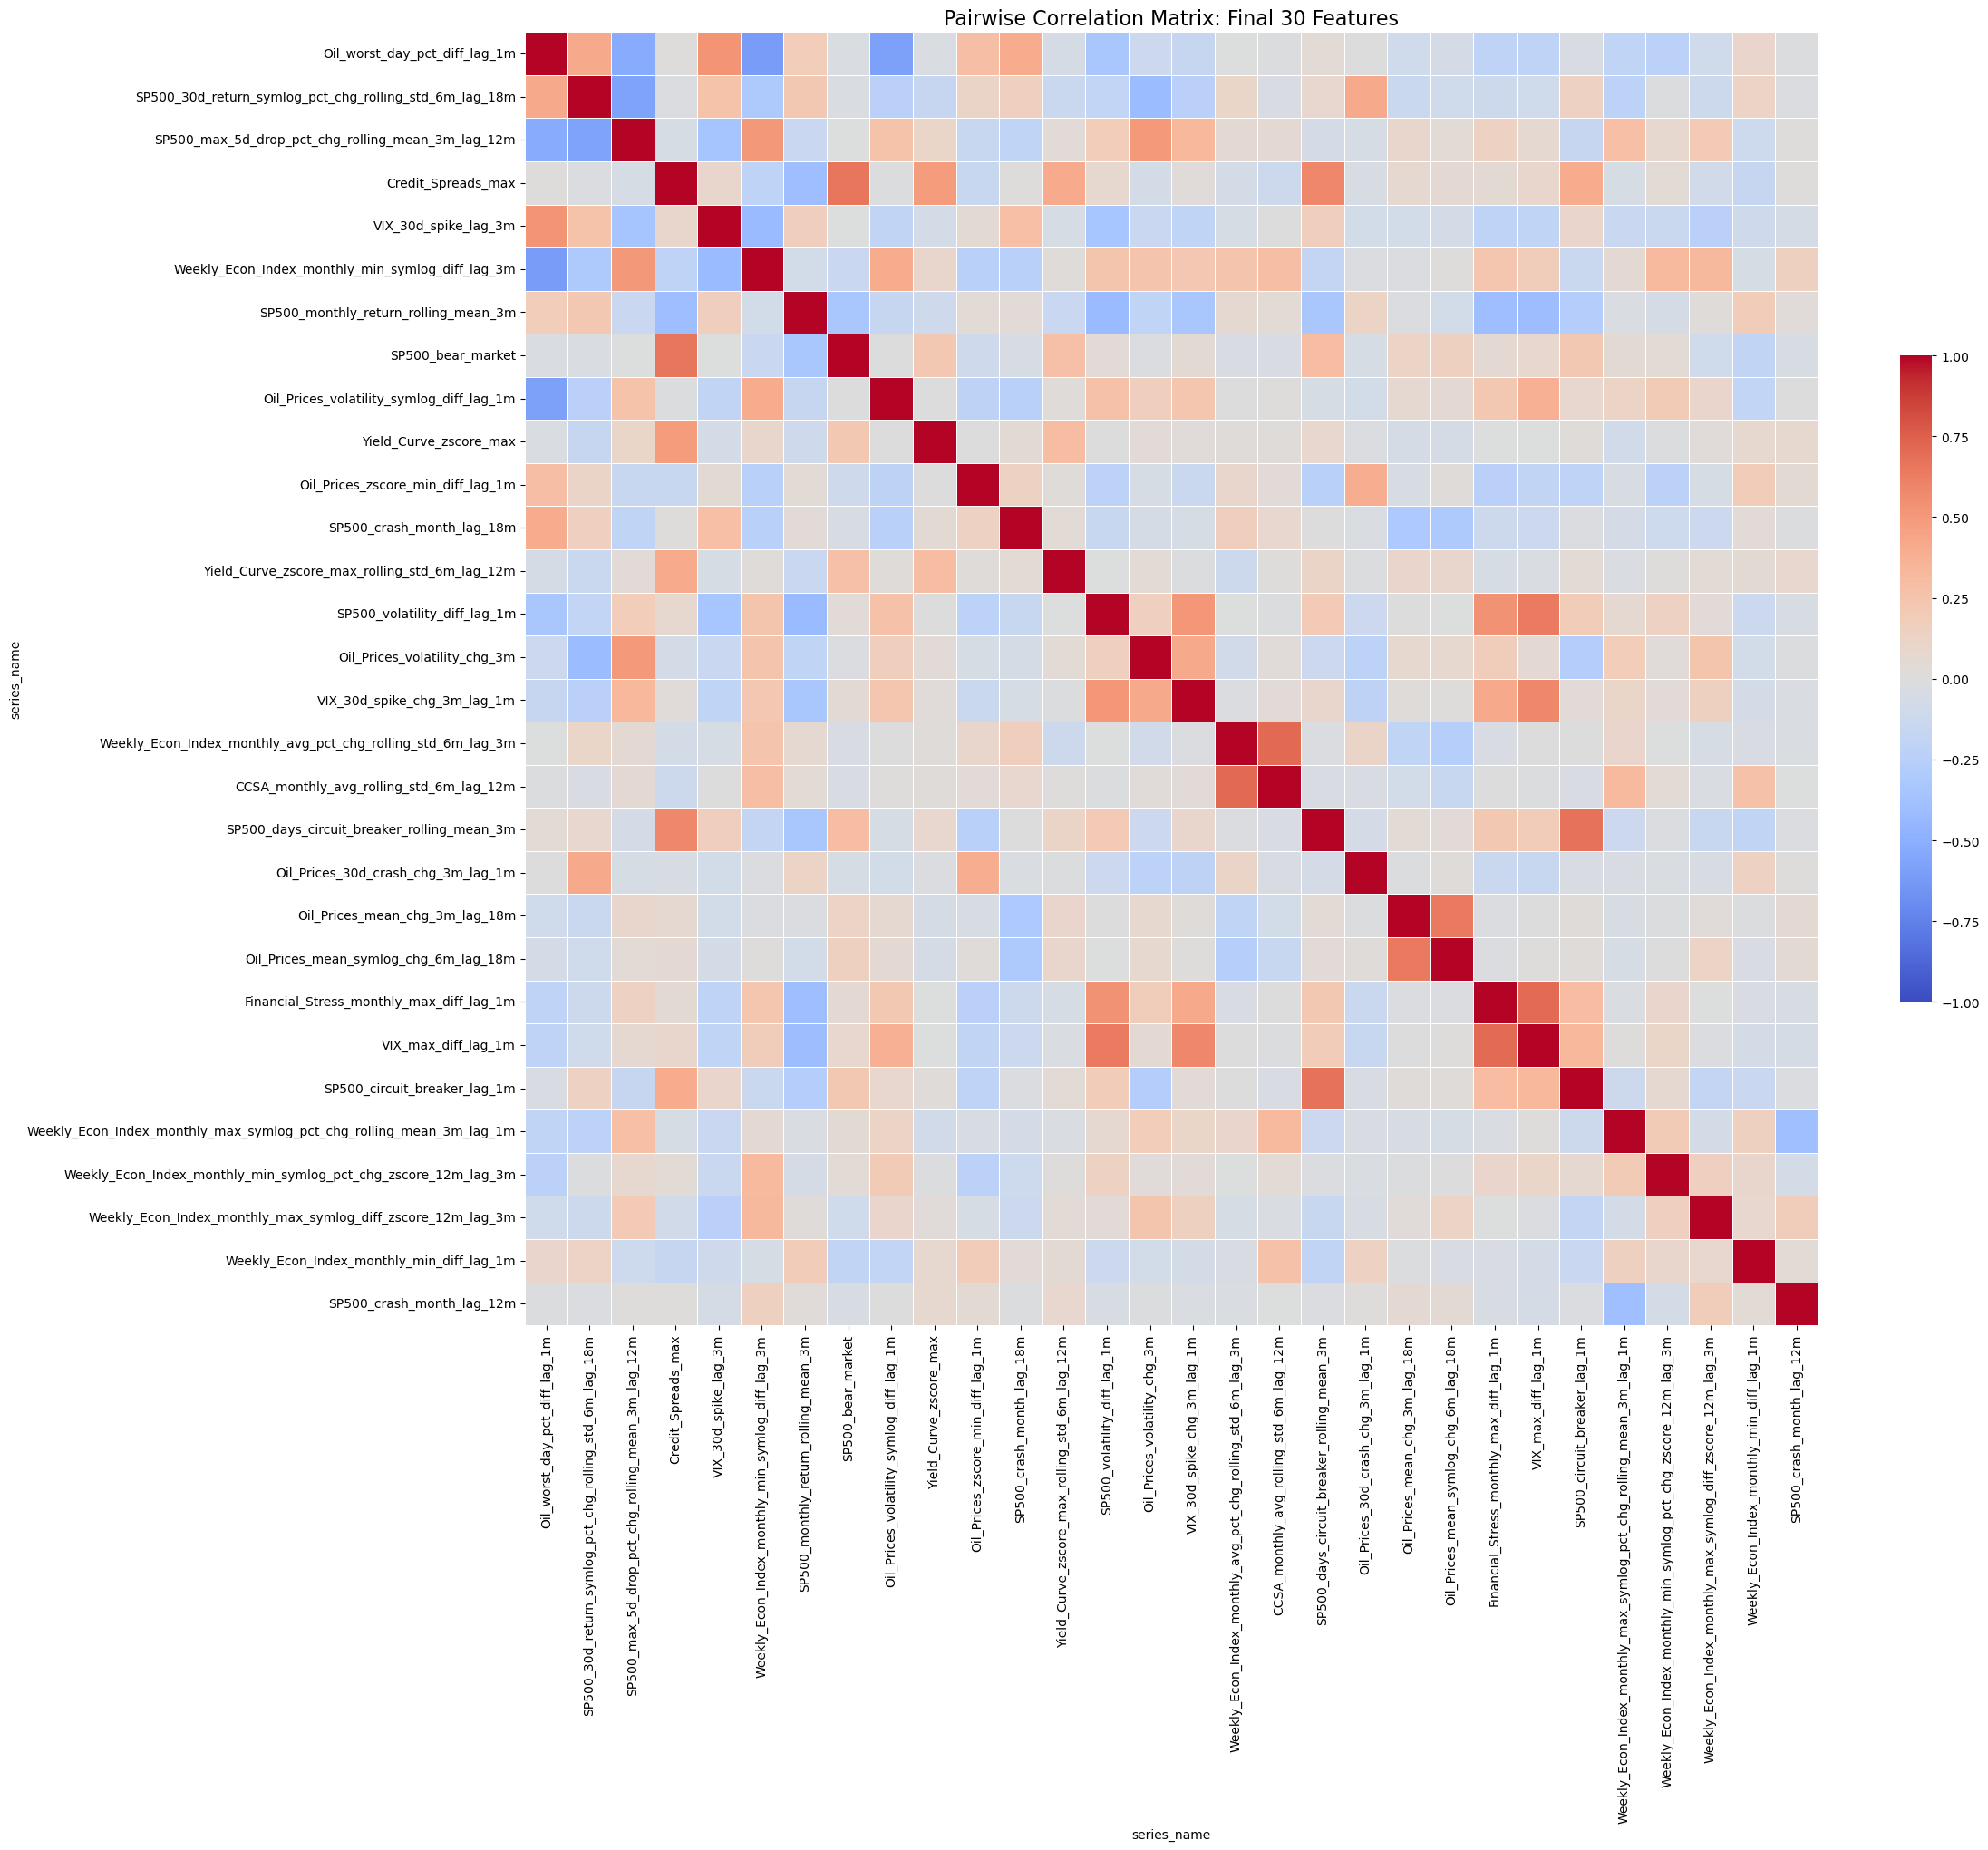


--- Remaining High Correlations (>0.8) ---
Weekly_Econ_Index_monthly_avg_pct_chg_rolling_std_6m_lag_3m vs CCSA_monthly_avg_rolling_std_6m_lag_12m: 0.7140
Financial_Stress_monthly_max_diff_lag_1m vs VIX_max_diff_lag_1m: 0.7074


In [ ]:
# --- 9. Final Feature Correlation Matrix ---
# Visualize pairwise correlations of the FINAL feature set to check for remaining multicollinearity.
# Features come from Manual Adjustments (df_final_manual) or previous steps.

print("=" * 80)
print("  FINAL CORRELATION MATRIX")
print("=" * 80)

# 1. Retrieve Features
final_features = []
if 'df_final_manual' in locals():
    final_features = df_final_manual['Feature'].tolist()
    print(f"Using features from Manual Adjustments ({len(final_features)} features)")
elif 'df_final' in locals():
    final_features = df_final['Feature'].tolist()
    print(f"Using features from VIF Analysis ({len(final_features)} features)")
else:
    print("WARNING: No final feature set found. Please run previous cells.")
    
# 2. Compute Correlation Matrix & Plot
if final_features:
    # Use df_pivot (winsorized)
    X_final = df_pivot[final_features].copy()
    
    # Calculate correlation matrix
    corr_matrix = X_final.corr()
    
    # Plot Heatmap
    plt.figure(figsize=(24, 20))
    sns.heatmap(
        corr_matrix, 
        annot=False, 
        cmap='coolwarm', 
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": .5}
    )
    plt.title(f"Pairwise Correlation Matrix: Final {len(final_features)} Features", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # 3. Report High Correlations (>0.8)
    print("\n--- Remaining High Correlations (>0.7) ---")
    # Get upper triangle to avoid duplicates
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Stack to get pairs
    high_pairs = upper.stack()
    
    # Filter > 0.8
    high_pairs_filtered = high_pairs[high_pairs.abs() > 0.7]
    
    if not high_pairs_filtered.empty:
        # Sort by absolute correlation
        sorted_pairs = high_pairs_filtered.abs().sort_values(ascending=False)
        
        for idx, val_abs in sorted_pairs.items():
            # Get signed value
            val_signed = high_pairs_filtered[idx]
            print(f"{idx[0]} vs {idx[1]}: {val_signed:.4f}")
    else:
        print("None found.")
else:
    print("No features to analyze.")


In [107]:
# --- 10. NSA Analysis: Within-Group Feature Selection ---
# Replicating the pipeline for NSA Winsorized Target (`y_target_nsa`).
# 1. Select Top 100 correlated features per group (with NSA target).
# 2. Prune using VIF (Threshold=10), prioritizing NSA correlation.
# 3. ROBUSTNESS: Require >100 valid overlapping observations.

print("=" * 80)
print("  NSA TARGET ANALYSIS: WITHIN-GROUP VIF")
print("=" * 80)

# Ensure data availability
if 'y_target_nsa' not in locals():
    print("Error: `y_target_nsa` not found. Please run Data Loading cells.")
    y_target_nsa_analysis = pd.Series(dtype=float)
else:
    # Use global variable
    y_target_nsa_analysis = y_target_nsa

# Helper Function (Local to this analysis)
def iterative_vif_pruning_nsa(X, y, group_name, top_k=100, threshold=10.0, min_obs=100):
    """
    Iteratively removes features with VIF > threshold.
    Prioritizes keeping features with higher absolute correlation to `y`.
    Enforces `min_obs` valid overlapping data points.
    """
    if X.empty: return []

    # 1. robust Pre-Filter: Check Valid Overlap
    # Align X and y globally first
    common_idx_all = X.index.intersection(y.index)
    X_aligned = X.loc[common_idx_all]
    y_aligned = y.loc[common_idx_all]
    
    # Count valid observations per feature
    valid_counts = X_aligned.notna().sum()
    valid_mask = valid_counts >= min_obs
    
    # Filter features
    X_valid = X_aligned.loc[:, valid_mask]
    dropped_cols = len(X.columns) - len(X_valid.columns)
    if dropped_cols > 0:
        # print(f"  {group_name}: Dropped {dropped_cols} features with < {min_obs} valid obs.")
        pass

    if X_valid.empty:
        print(f"  Skipping {group_name}: No features with >= {min_obs} valid observations.")
        return []

    # 2. Pairwise correlations with Target (using valid features only)
    corrs = X_valid.corrwith(y_aligned).abs().sort_values(ascending=False)
    
    # Identify Champion (highest corr feature) for potential constraints
    champion_feature = corrs.index[0] if not corrs.empty else None
    features_above_03 = set(corrs[corrs > 0.3].index)
    has_high_corr = len(features_above_03) > 0
    
    top_features = corrs.head(top_k).index.tolist()
    X_curr = X_valid[top_features].copy()
    
    # 3. Align Matrix for VIF (Intersection of Top K)
    # Note: Since we pre-filtered for min_obs individually, the intersection 
    # of ALL top 100 might still be smaller, but much less likely to be tiny 
    # (unless features are disjoint, which is rare in a group).
    common_idx = X_curr.dropna().index.intersection(y_aligned.dropna().index)
    X_curr = X_curr.loc[common_idx]
    y_curr = y_aligned.loc[common_idx]
    
    # Check final window size
    if len(X_curr) < 20:
        print(f"  Skipping {group_name}: Combined window too small ({len(X_curr)} rows).")
        # Fallback: Can we reduce Top K to find a better window? 
        # For now, just return empty list or maybe top 1 feature?
        # Returning top 1 feature is safer than nothing.
        if champion_feature:
             return [champion_feature]
        return []
        
    # 4. Iterative VIF reduction
    iteration = 0
    while X_curr.shape[1] > 1:
        try:
            vifs = [variance_inflation_factor(X_curr.values, i) for i in range(X_curr.shape[1])]
        except Exception as e:
            print(f"  VIF Error: {e}. Stopping.")
            break
        
        max_vif = max(vifs)
        if max_vif <= threshold:
            break
        
        max_idx = vifs.index(max_vif)
        feature_max = X_curr.columns[max_idx]
        
        # Find most correlated partner
        curr_corr = X_curr.corr().abs()
        collinear_partner = curr_corr[feature_max].drop(feature_max).idxmax()
        
        # Compare correlations with TARGET
        corr_max = abs(X_curr[feature_max].corr(y_curr))
        corr_partner = abs(X_curr[collinear_partner].corr(y_curr))
        
        if corr_max < corr_partner:
            drop_cand = feature_max
            keep_cand = collinear_partner
        else:
            drop_cand = collinear_partner
            keep_cand = feature_max
        
        # 5. Constraint: preserve Champion if it's high-quality (>0.3)
        if has_high_corr and drop_cand == champion_feature and corr_max > 0.3:
            # Try dropping partner instead
            drop_cand = keep_cand
            
        X_curr = X_curr.drop(columns=[drop_cand])
        iteration += 1
    
    return X_curr.columns.tolist()

# Run Selection Loop
selected_features_nsa = {}
nsa_stats = []

# Scan for groups
uniq_groups = sorted(list(set(series_groups.keys()))) # Assuming series_groups defined in Cell 16

for group_name in tqdm(uniq_groups, desc="NSA VIF Selection"):
    # Identify columns belonging to this group
    # Logic: Column starts with any base_series from the group?
    # series_groups is {Group: [Series1, Series2...]}
    # Feature names are like `Series1_transform...`
    base_list = series_groups[group_name]
    
    group_cols = []
    for col in df_pivot.columns:
        # Check if derived from this group
        # Faster check:
        # split by first underscore?
        # Or Just iterate base_list.
        for base in base_list:
            if col == base or col.startswith(base + '_'):
                group_cols.append(col)
                break
    
    if not group_cols:
        continue
        
    X_group = df_pivot[group_cols]
    
    selected = iterative_vif_pruning_nsa(X_group, y_target_nsa_analysis, group_name)
    selected_features_nsa[group_name] = selected
    
    nsa_stats.append({
        'Group': group_name,
        'Original_Count': len(group_cols),
        'Selected_Count': len(selected)
    })

print("\n--- NSA Selection Summary ---")
display(pd.DataFrame(nsa_stats).set_index('Group'))


  NSA TARGET ANALYSIS: WITHIN-GROUP VIF


NSA VIF Selection:   0%|          | 0/11 [00:00<?, ?it/s]


--- NSA Selection Summary ---


,Original_Count,Selected_Count
Group,,
CCNSA (Continued Claims NSA),504,17
CCSA (Continued Claims SA),468,27
Credit Spreads,1344,30
Financial Stress,576,35
Oil Prices,960,43
SP500,1644,56
SP500 (Binary Regimes),18,18
VIX,960,26
VIX (Binary Regimes),12,12


In [108]:
# --- 11. NSA Cross-Group VIF Analysis ---
# STRICT RULES:
# 1. Prioritize correlation with NSA Winsorized Target (`y_target_nsa`).
# 2. NO STALEMATE: Always drop lower correlation feature.
# 3. CONSISTENCY: Use Global Pairwise Correlations (NSA).

print("=" * 80)
print("  NSA CROSS-GROUP VIF ANALYSIS")
print("=" * 80)

if selected_features_nsa:
    # Gather
    all_selected_nsa = []
    feature_to_group_nsa = {}
    for group_name, feats in selected_features_nsa.items():
        all_selected_nsa.extend(feats)
        for f in feats:
            feature_to_group_nsa[f] = group_name
            
    # Calculate GLOBAL NSA Correlations (Signed)
    print("Calculating Global NSA Correlations...")
    global_corrs_nsa_signed = df_pivot.corrwith(y_target_nsa)
    global_corrs_nsa_abs = global_corrs_nsa_signed.abs()
    
    # Setup VIF matrix
    X_combined = df_pivot[all_selected_nsa].copy()
    common_idx = X_combined.dropna().index.intersection(y_target_nsa.dropna().index)
    X_clean = X_combined.loc[common_idx]
    
    # Identify NSA Champions
    group_champions_nsa = {}
    for group_name in selected_features_nsa.keys():
        group_feats = [f for f in all_selected_nsa if feature_to_group_nsa.get(f) == group_name]
        if group_feats:
            best_feat = global_corrs_nsa_abs[group_feats].idxmax()
            best_corr = global_corrs_nsa_abs[best_feat]
            group_champions_nsa[group_name] = best_feat
            print(f"  Group '{group_name}' Champion: {best_feat} (Corr={best_corr:.4f})")
            
    # VIF Loop
    X_final_nsa = X_clean.copy()
    iteration = 0
    dropped_stats_nsa = []
    
    while X_final_nsa.shape[1] > 1:
        try:
            vifs = pd.Series(
                [variance_inflation_factor(X_final_nsa.values, i) for i in range(X_final_nsa.shape[1])],
                index=X_final_nsa.columns
            )
        except:
            break
            
        max_vif = vifs.max()
        if max_vif <= 10:
            break
            
        feature_max = vifs.idxmax()
        curr_corr = X_final_nsa.corr().abs()
        collinear_partner = curr_corr[feature_max].drop(feature_max).idxmax()
        
        # Compare NSA TARGET correlations (GLOBAL ABS)
        corr_max = global_corrs_nsa_abs[feature_max]
        corr_partner = global_corrs_nsa_abs[collinear_partner]
        
        if corr_max < corr_partner:
            drop_cand, keep_cand = feature_max, collinear_partner
            corr_drop, corr_keep = corr_max, corr_partner
        else:
            drop_cand, keep_cand = collinear_partner, feature_max
            corr_drop, corr_keep = corr_partner, corr_max
            
        # Logging
        drop_group = feature_to_group_nsa.get(drop_cand)
        is_champion = (drop_cand == group_champions_nsa.get(drop_group))
        remaining = [f for f in X_final_nsa.columns if feature_to_group_nsa.get(f) == drop_group]
        is_last = (len(remaining) == 1)
        
        log_msg = f"  Drop {drop_cand} (VIF={vifs[drop_cand] if drop_cand==feature_max else 'Partner'}, Corr={corr_drop:.4f}) vs {keep_cand} (Corr={corr_keep:.4f})"
        
        event_type = []
        if is_champion:
            log_msg += " [CHAMPION]"
            event_type.append("Champion")
        if is_last:
            log_msg += " [LAST SURVIVOR]"
            event_type.append("Last Survivor")
            
        print(log_msg)
        
        if event_type:
            dropped_stats_nsa.append({
                'Feature': drop_cand,
                'Group': drop_group,
                'Type': ", ".join(event_type),
                'VIF_at_Drop': vifs[drop_cand] if drop_cand in vifs else vifs.max(),
                'Corr_NSA_Winsorized': corr_drop,
                'Dropped_By': keep_cand
            })
            
        X_final_nsa = X_final_nsa.drop(columns=[drop_cand])
        iteration += 1

    print(f"\nNSA Cross-group VIF complete: {X_final_nsa.shape[1]} features retained.")
    
    # Final Table
    final_vifs = [variance_inflation_factor(X_final_nsa.values, i) for i in range(X_final_nsa.shape[1])]
    
    nsa_table = []
    for idx, feat in enumerate(X_final_nsa.columns):
        nsa_table.append({
            'Group': feature_to_group_nsa.get(feat, 'Other'),
            'Feature': feat,
            'Short_Name': shorten_name(feat, feature_to_group_nsa.get(feat, 'Other')),
            'VIF': final_vifs[idx],
            'Corr_NSA': global_corrs_nsa_signed[feat],
            'Abs_Corr_NSA': abs(global_corrs_nsa_signed[feat])
        })
        
    df_final_nsa = pd.DataFrame(nsa_table).sort_values('Abs_Corr_NSA', ascending=False)
    
    print(f"\n--- Final Selected Features (NSA Target) ---")
    display(df_final_nsa[['Group', 'Short_Name', 'VIF', 'Corr_NSA']].style.format({
        'VIF': '{:.2f}',
        'Corr_NSA': '{:.4f}'
    }).background_gradient(cmap='coolwarm', axis=0))
    
    if dropped_stats_nsa:
        print(f"\n--- Dropped Champions & Last Survivors (NSA) ---")
        display(pd.DataFrame(dropped_stats_nsa))



  NSA CROSS-GROUP VIF ANALYSIS
Calculating Global NSA Correlations...
  Group 'CCNSA (Continued Claims NSA)' Champion: CCNSA_monthly_avg_diff_zscore_12m (Corr=0.7348)
  Group 'CCSA (Continued Claims SA)' Champion: CCSA_max_spike_symlog_zscore_3m (Corr=0.2192)
  Group 'Credit Spreads' Champion: Credit_Spreads_acceleration_chg_3m_lag_6m (Corr=0.1691)
  Group 'Financial Stress' Champion: Financial_Stress_monthly_min_pct_chg_lag_3m (Corr=0.1767)
  Group 'Oil Prices' Champion: Oil_Prices_mean_symlog_pct_chg_lag_1m (Corr=0.2846)
  Group 'SP500' Champion: SP500_30d_return_symlog_pct_chg_rolling_mean_3m_lag_18m (Corr=0.2164)
  Group 'SP500 (Binary Regimes)' Champion: SP500_bear_market (Corr=0.1181)
  Group 'VIX' Champion: VIX_mean_symlog_pct_chg_rolling_mean_3m_lag_12m (Corr=0.1575)
  Group 'VIX (Binary Regimes)' Champion: VIX_panic_regime (Corr=0.1393)
  Group 'Weekly Economic Index' Champion: Weekly_Econ_Index_monthly_max_diff (Corr=0.2383)
  Group 'Yield Curve' Champion: Yield_Curve_monthly

,Group,Short_Name,VIF,Corr_NSA
0,CCNSA (Continued Claims NSA),monthly_avg_diff_zscore_12m,1.11,-0.7348
29,Weekly Economic Index,monthly_avg_diff_zscore_12m_lag_12m,4.79,0.1638
1,CCSA (Continued Claims SA),max_spike_symlog_zscore_3m_lag_6m,3.48,-0.1618
6,Oil Prices,Oil_worst_day_pct_symlog_chg_3m_lag_6m,4.09,-0.1492
32,Yield Curve,monthly_chg_symlog_diff_zscore_3m_lag_1m,4.64,-0.1466
33,Yield Curve,avg_symlog_diff_lag_3m,6.97,-0.1431
24,VIX (Binary Regimes),VIX_panic_regime,nan,-0.1393
7,Oil Prices,zscore_min_symlog_zscore_3m_lag_1m,3.41,0.1392
21,VIX,mean_chg_3m_lag_12m,8.44,0.1379
3,Financial Stress,monthly_min_symlog_diff_zscore_3m,4.03,0.1362



--- Dropped Champions & Last Survivors (NSA) ---


,Feature,Group,Type,VIF_at_Drop,Corr_NSA_Winsorized,Dropped_By
0,Financial_Stress_monthly_min_pct_chg_lag_3m,Financial Stress,Champion,inf,0.1767,CCNSA_monthly_avg_diff_zscore_12m
1,CCSA_max_spike_symlog_zscore_3m,CCSA (Continued Claims SA),Champion,inf,0.2192,CCNSA_monthly_avg_diff_zscore_12m
2,Weekly_Econ_Index_monthly_max_diff,Weekly Economic Index,Champion,inf,0.2383,CCNSA_monthly_avg_diff_zscore_12m
3,Credit_Spreads_acceleration_chg_3m_lag_6m,Credit Spreads,Champion,inf,0.1691,CCNSA_monthly_avg_diff_zscore_12m
4,Yield_Curve_monthly_chg_lag_3m,Yield Curve,Champion,inf,0.1531,CCNSA_monthly_avg_diff_zscore_12m
5,SP500_30d_return_symlog_pct_chg_rolling_mean_3m_lag_18m,SP500,Champion,inf,0.2164,CCNSA_monthly_avg_diff_zscore_12m
6,Oil_Prices_mean_symlog_pct_chg_lag_1m,Oil Prices,Champion,inf,0.2846,CCNSA_monthly_avg_diff_zscore_12m
7,VIX_mean_symlog_pct_chg_rolling_mean_3m_lag_12m,VIX,Champion,inf,0.1575,CCNSA_monthly_avg_diff_zscore_12m


In [109]:
# --- 12. NSA Manual Adjustments ---
# EXPERT OVERRIDE for NSA Feature Set.
# Add/Drop features as needed.

print("=" * 80)
print("  NSA MANUAL ADJUSTMENTS")
print("=" * 80)

# Placeholder Lists
features_to_drop_nsa = [
    'VIX_panic_regime_lag_3m', 'SP500_crash_month_lag_6m', 'VIX_panic_regime_lag_6m', 'SP500_crash_month_lag_3m',
    'SP500_bear_market_lag_3m', 'SP500_crash_month', 'SP500_bear_market_lag_1m', 'SP500_bear_market', 'VIX_panic_regime',
    'SP500_crash_month_lag_1m', 'VIX_panic_regime_lag_1m', 'Financial_Stress_monthly_avg_symlog_diff_zscore_3m'
]

features_to_add_nsa = [
    'Weekly_Econ_Index_monthly_max_diff', 'Credit_Spreads_acceleration_chg_3m_lag_6m', 'Yield_Curve_monthly_chg_lag_3m',
    'Oil_Prices_mean_symlog_pct_chg_lag_1m'
]

current_features_nsa = df_final_nsa['Feature'].tolist() if 'df_final_nsa' in locals() else []

# Drop
for f in features_to_drop_nsa:
    if f in current_features_nsa:
        current_features_nsa.remove(f)
        print(f"Dropped {f}")

# Add
for f in features_to_add_nsa:
    if f not in current_features_nsa and f in df_pivot.columns:
        current_features_nsa.append(f)
        print(f"Added {f}")
        
# Final Check
print(f"Final Count: {len(current_features_nsa)}")

# Recalc Table
if current_features_nsa:
    X_curr = df_pivot[current_features_nsa].copy()
    common = X_curr.dropna().index.intersection(y_target_nsa.dropna().index)
    X_curr = X_curr.loc[common]
    
    final_vifs = [variance_inflation_factor(X_curr.values, i) for i in range(X_curr.shape[1])]
    
    manual_table_nsa = []
    for idx, feat in enumerate(X_curr.columns):
        manual_table_nsa.append({
            'Feature': feat,
            'VIF': final_vifs[idx],
            'Corr_NSA': global_corrs_nsa_signed.get(feat, np.nan)
        })
        
    df_final_manual_nsa = pd.DataFrame(manual_table_nsa).sort_values('Corr_NSA', key=abs, ascending=False)
    display(df_final_manual_nsa)



  NSA MANUAL ADJUSTMENTS
Dropped VIX_panic_regime_lag_3m
Dropped SP500_crash_month_lag_6m
Dropped VIX_panic_regime_lag_6m
Dropped SP500_crash_month_lag_3m
Dropped SP500_bear_market_lag_3m
Dropped SP500_crash_month
Dropped SP500_bear_market_lag_1m
Dropped SP500_bear_market
Dropped VIX_panic_regime
Dropped SP500_crash_month_lag_1m
Dropped VIX_panic_regime_lag_1m
Dropped Financial_Stress_monthly_avg_symlog_diff_zscore_3m
Added Weekly_Econ_Index_monthly_max_diff
Added Credit_Spreads_acceleration_chg_3m_lag_6m
Added Yield_Curve_monthly_chg_lag_3m
Added Oil_Prices_mean_symlog_pct_chg_lag_1m
Final Count: 31


,Feature,VIF,Corr_NSA
0,CCNSA_monthly_avg_diff_zscore_12m,1.2208,-0.7348
30,Oil_Prices_mean_symlog_pct_chg_lag_1m,3.2436,0.2846
27,Weekly_Econ_Index_monthly_max_diff,2.0727,0.2383
28,Credit_Spreads_acceleration_chg_3m_lag_6m,2.7150,-0.1691
1,Weekly_Econ_Index_monthly_avg_diff_zscore_12m_lag_12m,1.3891,0.1638
2,CCSA_max_spike_symlog_zscore_3m_lag_6m,1.2094,-0.1618
29,Yield_Curve_monthly_chg_lag_3m,2.3034,-0.1531
3,Oil_worst_day_pct_symlog_chg_3m_lag_6m,1.6743,-0.1492
4,Yield_Curve_monthly_chg_symlog_diff_zscore_3m_lag_1m,1.2041,-0.1466
5,Yield_Curve_avg_symlog_diff_lag_3m,2.4222,-0.1431


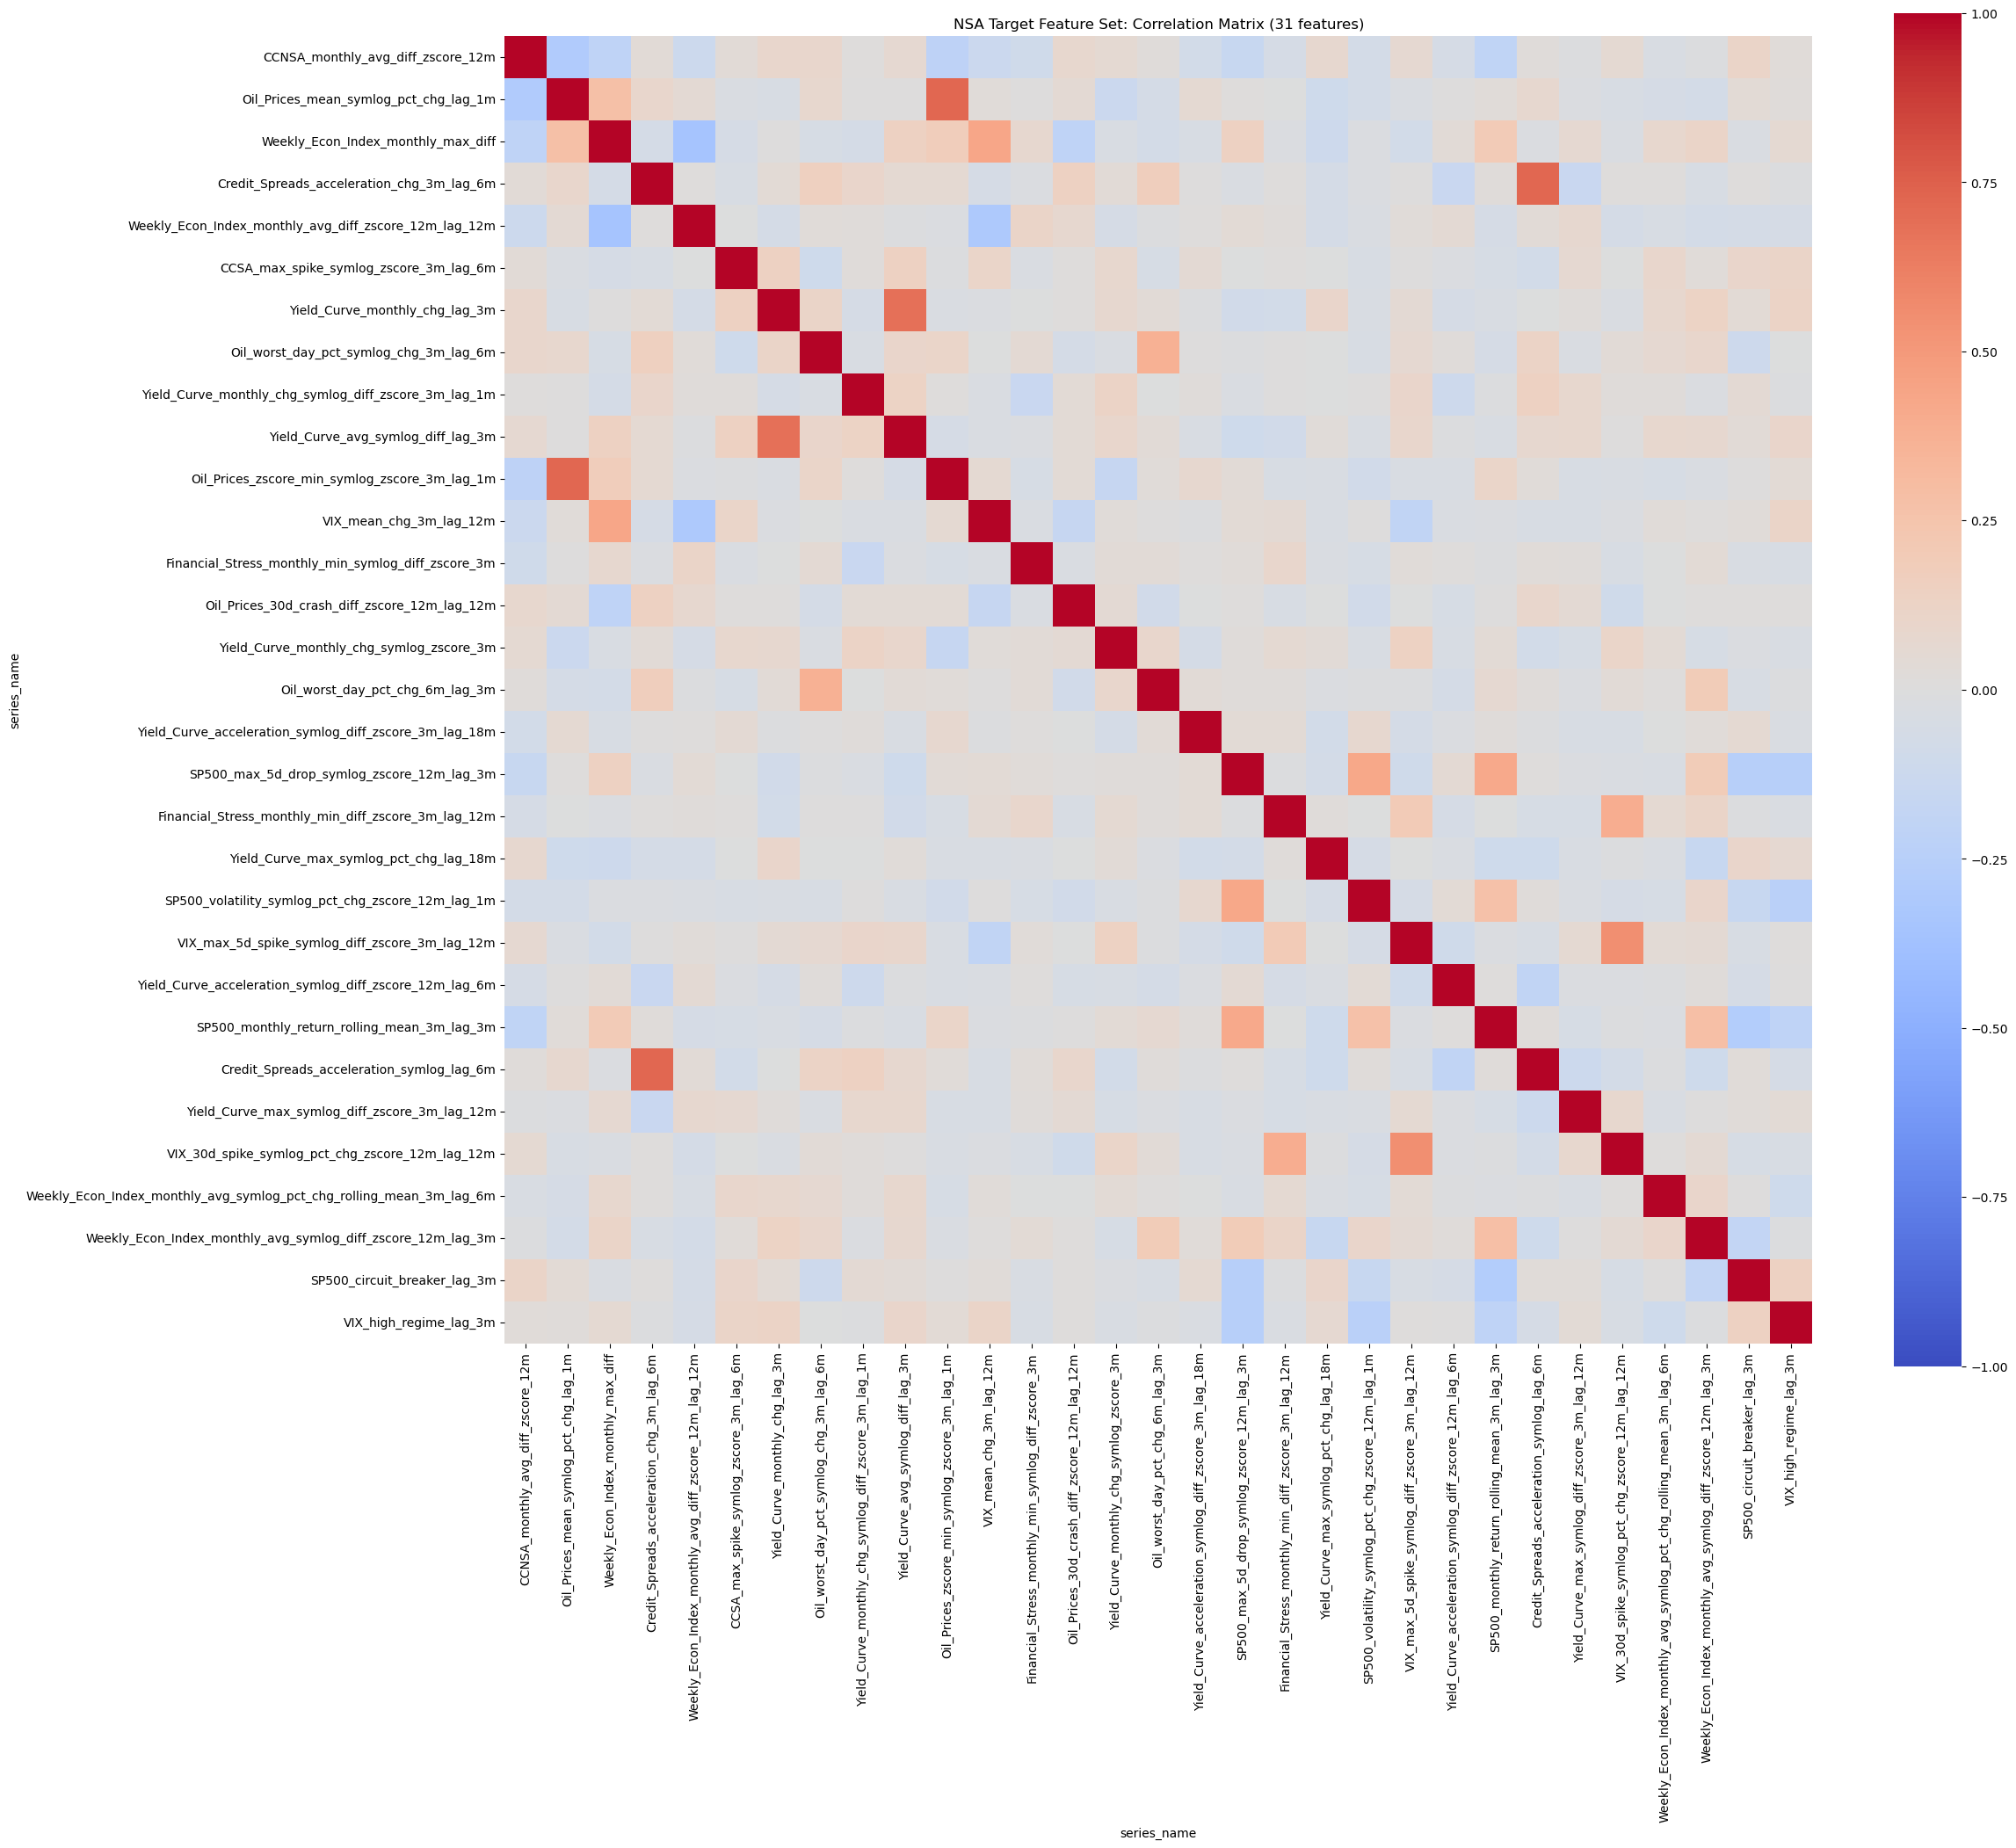

In [110]:
# --- 13. NSA Final Correlation Matrix ---
if 'df_final_manual_nsa' in locals() and not df_final_manual_nsa.empty:
    feats = df_final_manual_nsa['Feature'].tolist()
    X_viz = df_pivot[feats].copy()
    corr_matrix = X_viz.corr()
    
    plt.figure(figsize=(24, 20))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
    plt.title(f"NSA Target Feature Set: Correlation Matrix ({len(feats)} features)")
    plt.show()
else:
    print("No features to visualize.")



In [113]:
# --- 14. Non-Linear Analysis: Mutual Information (MI) ---
# Detects non-linear dependencies (e.g., U-shaped) that Pearson correlation misses.
# Calculates MI score for ALL valid features against SA and NSA targets.

print("=" * 80)
print("  MUTUAL INFORMATION SCREENING")
print("=" * 80)

from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer

def calculate_mi_scores(X, y, top_k=50):
    # Align target and features on dates
    common = X.index.intersection(y.dropna().index)
    
    if len(common) < 50:
        print(f"  Warning: Only {len(common)} samples for MI analysis.")
        return pd.Series()
        
    X_aligned = X.loc[common].copy()
    y_aligned = y.loc[common].copy()
    
    # Cleaning Step 1: Replace Infinities with NaN
    X_aligned = X_aligned.replace([np.inf, -np.inf], np.nan)
    
    # Cleaning Step 2: Drop columns that are completely empty after alignment
    X_aligned = X_aligned.dropna(axis=1, how='all')
    
    if X_aligned.empty:
        return pd.Series()

    # Cleaning Step 3: Impute Missing Values (Median) since MI requires dense input
    # Dropping rows with *any* NaN would be too aggressive for this wide dataset
    imputer = SimpleImputer(strategy='median')
    X_clean = pd.DataFrame(imputer.fit_transform(X_aligned), columns=X_aligned.columns, index=X_aligned.index)
    
    # Run MI
    try:
        mi = mutual_info_regression(X_clean, y_aligned, random_state=42)
        mi = pd.Series(mi, index=X_clean.columns)
        return mi.sort_values(ascending=False).head(top_k)
    except Exception as e:
        print(f"  Error in MI Calc: {e}")
        return pd.Series()

# 1. Prepare Feature Set (Use df_pivot transformation)
# Filter: Valid features must have >100 obs to be worth checking
valid_cols = []
for col in df_pivot.columns:
    if df_pivot[col].notna().sum() > 100:
        valid_cols.append(col)
        
print(f"Analyzing {len(valid_cols)} features for Non-Linear Dependency...")
X_all = df_pivot[valid_cols].copy()

# 2. Run MI for SA
print("\n--- Top 20 MI Scores (SA Target) ---")
mi_sa = calculate_mi_scores(X_all, y_target, top_k=50)
if not mi_sa.empty:
    display(mi_sa.head(20).to_frame(name="MI_Score"))

# 3. Run MI for NSA
if 'y_target_nsa' in locals():
    print("\n--- Top 20 MI Scores (NSA Target) ---")
    mi_nsa = calculate_mi_scores(X_all, y_target_nsa, top_k=50)
    if not mi_nsa.empty:
        display(mi_nsa.head(20).to_frame(name="MI_Score"))
else:
    mi_nsa = pd.Series()



  MUTUAL INFORMATION SCREENING
Analyzing 8370 features for Non-Linear Dependency...

--- Top 20 MI Scores (SA Target) ---


,MI_Score
series_name,
CCSA_max_spike_symlog_chg_12m_lag_1m,0.2445
CCSA_max_spike_symlog_chg_6m,0.2251
CCNSA_monthly_avg_chg_12m,0.2249
Credit_Spreads_avg_symlog,0.2233
CCSA_max_spike_chg_12m,0.2209
CCSA_max_spike_chg_6m_lag_1m,0.2139
CCSA_monthly_avg_pct_chg_rolling_mean_3m,0.2138
CCSA_monthly_avg_symlog_chg_6m,0.2133
CCSA_monthly_avg_symlog_chg_12m,0.2128



--- Top 20 MI Scores (NSA Target) ---


,MI_Score
series_name,
CCNSA_monthly_avg_diff,0.6612
CCNSA_monthly_avg_symlog_diff,0.5857
CCNSA_monthly_avg_symlog_pct_chg,0.5855
CCNSA_monthly_avg_diff_zscore_12m,0.5849
CCNSA_monthly_avg_pct_chg,0.5834
CCNSA_monthly_avg_symlog_diff_zscore_12m,0.5806
CCNSA_monthly_avg_pct_chg_zscore_12m,0.5800
CCNSA_monthly_avg_symlog_pct_chg_zscore_12m,0.5668
CCNSA_monthly_avg_symlog_zscore_3m,0.5508


In [114]:
# --- 15. Non-Linear Analysis: Random Forest Importance ---
# Trains a Random Forest on the full feature set to identify features 
# that contribute to prediction accuracy (capturing interactions).
# Uses Perumtation Importance to avoid bias towards high-cardinality features.

print("=" * 80)
print("  RANDOM FOREST PERMUTATION IMPORTANCE")
print("=" * 80)

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer

def run_rf_importance(X, y, target_name="Target", top_k=50):
    # Align
    common = X.index.intersection(y.dropna().index)
    if len(common) < 50:
        return pd.Series()
        
    X_aligned = X.loc[common].copy()
    y_aligned = y.loc[common].copy()
    
    # Cleaning: Replace Inf & Impute Median
    X_aligned = X_aligned.replace([np.inf, -np.inf], np.nan)
    X_aligned = X_aligned.dropna(axis=1, how='all')
    
    imputer = SimpleImputer(strategy='median')
    X_clean = pd.DataFrame(imputer.fit_transform(X_aligned), columns=X_aligned.columns, index=X_aligned.index)
    y_clean = y_aligned
    
    # Train RF
    print(f"Training RF on {len(X_clean)} rows, {X_clean.shape[1]} features ({target_name})...")
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_clean, y_clean)
    print(f"  R2 Score (In-Sample): {rf.score(X_clean, y_clean):.4f}")
    
    # Permutation Importance
    print("  Computing Permutation Importance...")
    result = permutation_importance(rf, X_clean, y_clean, n_repeats=5, random_state=42, n_jobs=-1)
    
    importances = pd.Series(result.importances_mean, index=X_clean.columns)
    return importances.sort_values(ascending=False).head(top_k)

# Run for SA
rf_imp_sa = run_rf_importance(X_all, y_target, "SA Target")
print("\n--- Top 20 RF Importance (SA) ---")
if not rf_imp_sa.empty:
    display(rf_imp_sa.head(20).to_frame(name="Importance"))

# Run for NSA
if 'y_target_nsa' in locals():
    rf_imp_nsa = run_rf_importance(X_all, y_target_nsa, "NSA Target")
    print("\n--- Top 20 RF Importance (NSA) ---")
    if not rf_imp_nsa.empty:
        display(rf_imp_nsa.head(20).to_frame(name="Importance"))
else:
    rf_imp_nsa = pd.Series()



  RANDOM FOREST PERMUTATION IMPORTANCE
Training RF on 430 rows, 8370 features (SA Target)...
  R2 Score (In-Sample): 0.8811
  Computing Permutation Importance...

--- Top 20 RF Importance (SA) ---


,Importance
series_name,
CCSA_max_spike_chg_3m,0.0175
Credit_Spreads_avg,0.0092
Yield_Curve_zscore_max_chg_12m_lag_1m,0.0084
CCSA_monthly_avg_chg_6m,0.0072
CCSA_max_spike_chg_6m,0.0066
Weekly_Econ_Index_monthly_avg_symlog_pct_chg_rolling_std_6m,0.0059
Yield_Curve_avg_symlog_chg_12m,0.0055
CCSA_monthly_avg_symlog_pct_chg_rolling_std_6m,0.0054
Credit_Spreads_max_chg_12m,0.0050


Training RF on 430 rows, 8370 features (NSA Target)...
  R2 Score (In-Sample): 0.9721
  Computing Permutation Importance...

--- Top 20 RF Importance (NSA) ---


,Importance
series_name,
CCNSA_monthly_avg_diff,0.1073
CCNSA_monthly_avg_diff_zscore_12m,0.0591
CCNSA_monthly_avg_zscore_3m,0.0520
CCNSA_monthly_avg_symlog_zscore_3m,0.0351
CCNSA_max_spike_diff,0.0120
CCNSA_monthly_avg_diff_zscore_12m_lag_3m,0.0086
CCNSA_monthly_avg_symlog_diff_zscore_3m_lag_3m,0.0063
CCNSA_monthly_avg_chg_3m_lag_6m,0.0062
CCNSA_monthly_avg_symlog_pct_chg_zscore_3m_lag_3m,0.0051


In [115]:
# --- 16. Feature Consolidation (Linear + Non-Linear Candidates) ---
# Merge the best features from all analyses:
# 1. VIF Selection (Linear/Multicollinearity-Safe)
# 2. Top MI Candidates (Non-Linear)
# 3. Top RF Candidates (Interaction/Importance)

print("=" * 80)
print("  FEATURE CONSOLIDATION")
print("=" * 80)

def consolidate_features(vif_list, mi_series, rf_series, top_n_nonlinear=10):
    # Start with VIF Features
    final_set = set(vif_list)
    
    # Add unique top Non-Linear
    mi_top = mi_series.head(top_n_nonlinear).index.tolist()
    rf_top = rf_series.head(top_n_nonlinear).index.tolist()
    
    added_mi = [f for f in mi_top if f not in final_set]
    added_rf = [f for f in rf_top if f not in final_set]
    
    final_set.update(added_mi)
    final_set.update(added_rf)
    
    print(f"Base (VIF): {len(vif_list)}")
    print(f"Added from MI: {len(added_mi)} ({added_mi})")
    print(f"Added from RF: {len(added_rf)} ({added_rf})")
    print(f"Total Unique: {len(final_set)}")
    
    return list(final_set)

# SA Consolidation
print("\n--- SA Target Consolidation ---")
# Get VIF list from Cell 18 results (df_final_manual)
if 'df_final_manual' in locals():
    vif_sa = df_final_manual['Feature'].tolist()
else:
    vif_sa = []
    print("Warning: SA VIF selection missing.")

final_sa_candidates = consolidate_features(vif_sa, mi_sa, rf_imp_sa)

# NSA Consolidation
print("\n--- NSA Target Consolidation ---")
# Get NSA VIF list from Cell 22 results (df_final_manual_nsa)
if 'df_final_manual_nsa' in locals():
    vif_nsa = df_final_manual_nsa['Feature'].tolist()
else:
    vif_nsa = []
    print("Warning: NSA VIF selection missing.")

final_nsa_candidates = consolidate_features(vif_nsa, mi_nsa, rf_imp_nsa)



  FEATURE CONSOLIDATION

--- SA Target Consolidation ---
Base (VIF): 30
Added from MI: 10 (['CCSA_max_spike_symlog_chg_12m_lag_1m', 'CCSA_max_spike_symlog_chg_6m', 'CCNSA_monthly_avg_chg_12m', 'Credit_Spreads_avg_symlog', 'CCSA_max_spike_chg_12m', 'CCSA_max_spike_chg_6m_lag_1m', 'CCSA_monthly_avg_pct_chg_rolling_mean_3m', 'CCSA_monthly_avg_symlog_chg_6m', 'CCSA_monthly_avg_symlog_chg_12m', 'CCNSA_monthly_avg_symlog_chg_12m'])
Added from RF: 10 (['CCSA_max_spike_chg_3m', 'Credit_Spreads_avg', 'Yield_Curve_zscore_max_chg_12m_lag_1m', 'CCSA_monthly_avg_chg_6m', 'CCSA_max_spike_chg_6m', 'Weekly_Econ_Index_monthly_avg_symlog_pct_chg_rolling_std_6m', 'Yield_Curve_avg_symlog_chg_12m', 'CCSA_monthly_avg_symlog_pct_chg_rolling_std_6m', 'Credit_Spreads_max_chg_12m', 'CCSA_monthly_avg_pct_chg_rolling_mean_3m_lag_1m'])
Total Unique: 50

--- NSA Target Consolidation ---
Base (VIF): 31
Added from MI: 9 (['CCNSA_monthly_avg_diff', 'CCNSA_monthly_avg_symlog_diff', 'CCNSA_monthly_avg_symlog_pct_chg', '

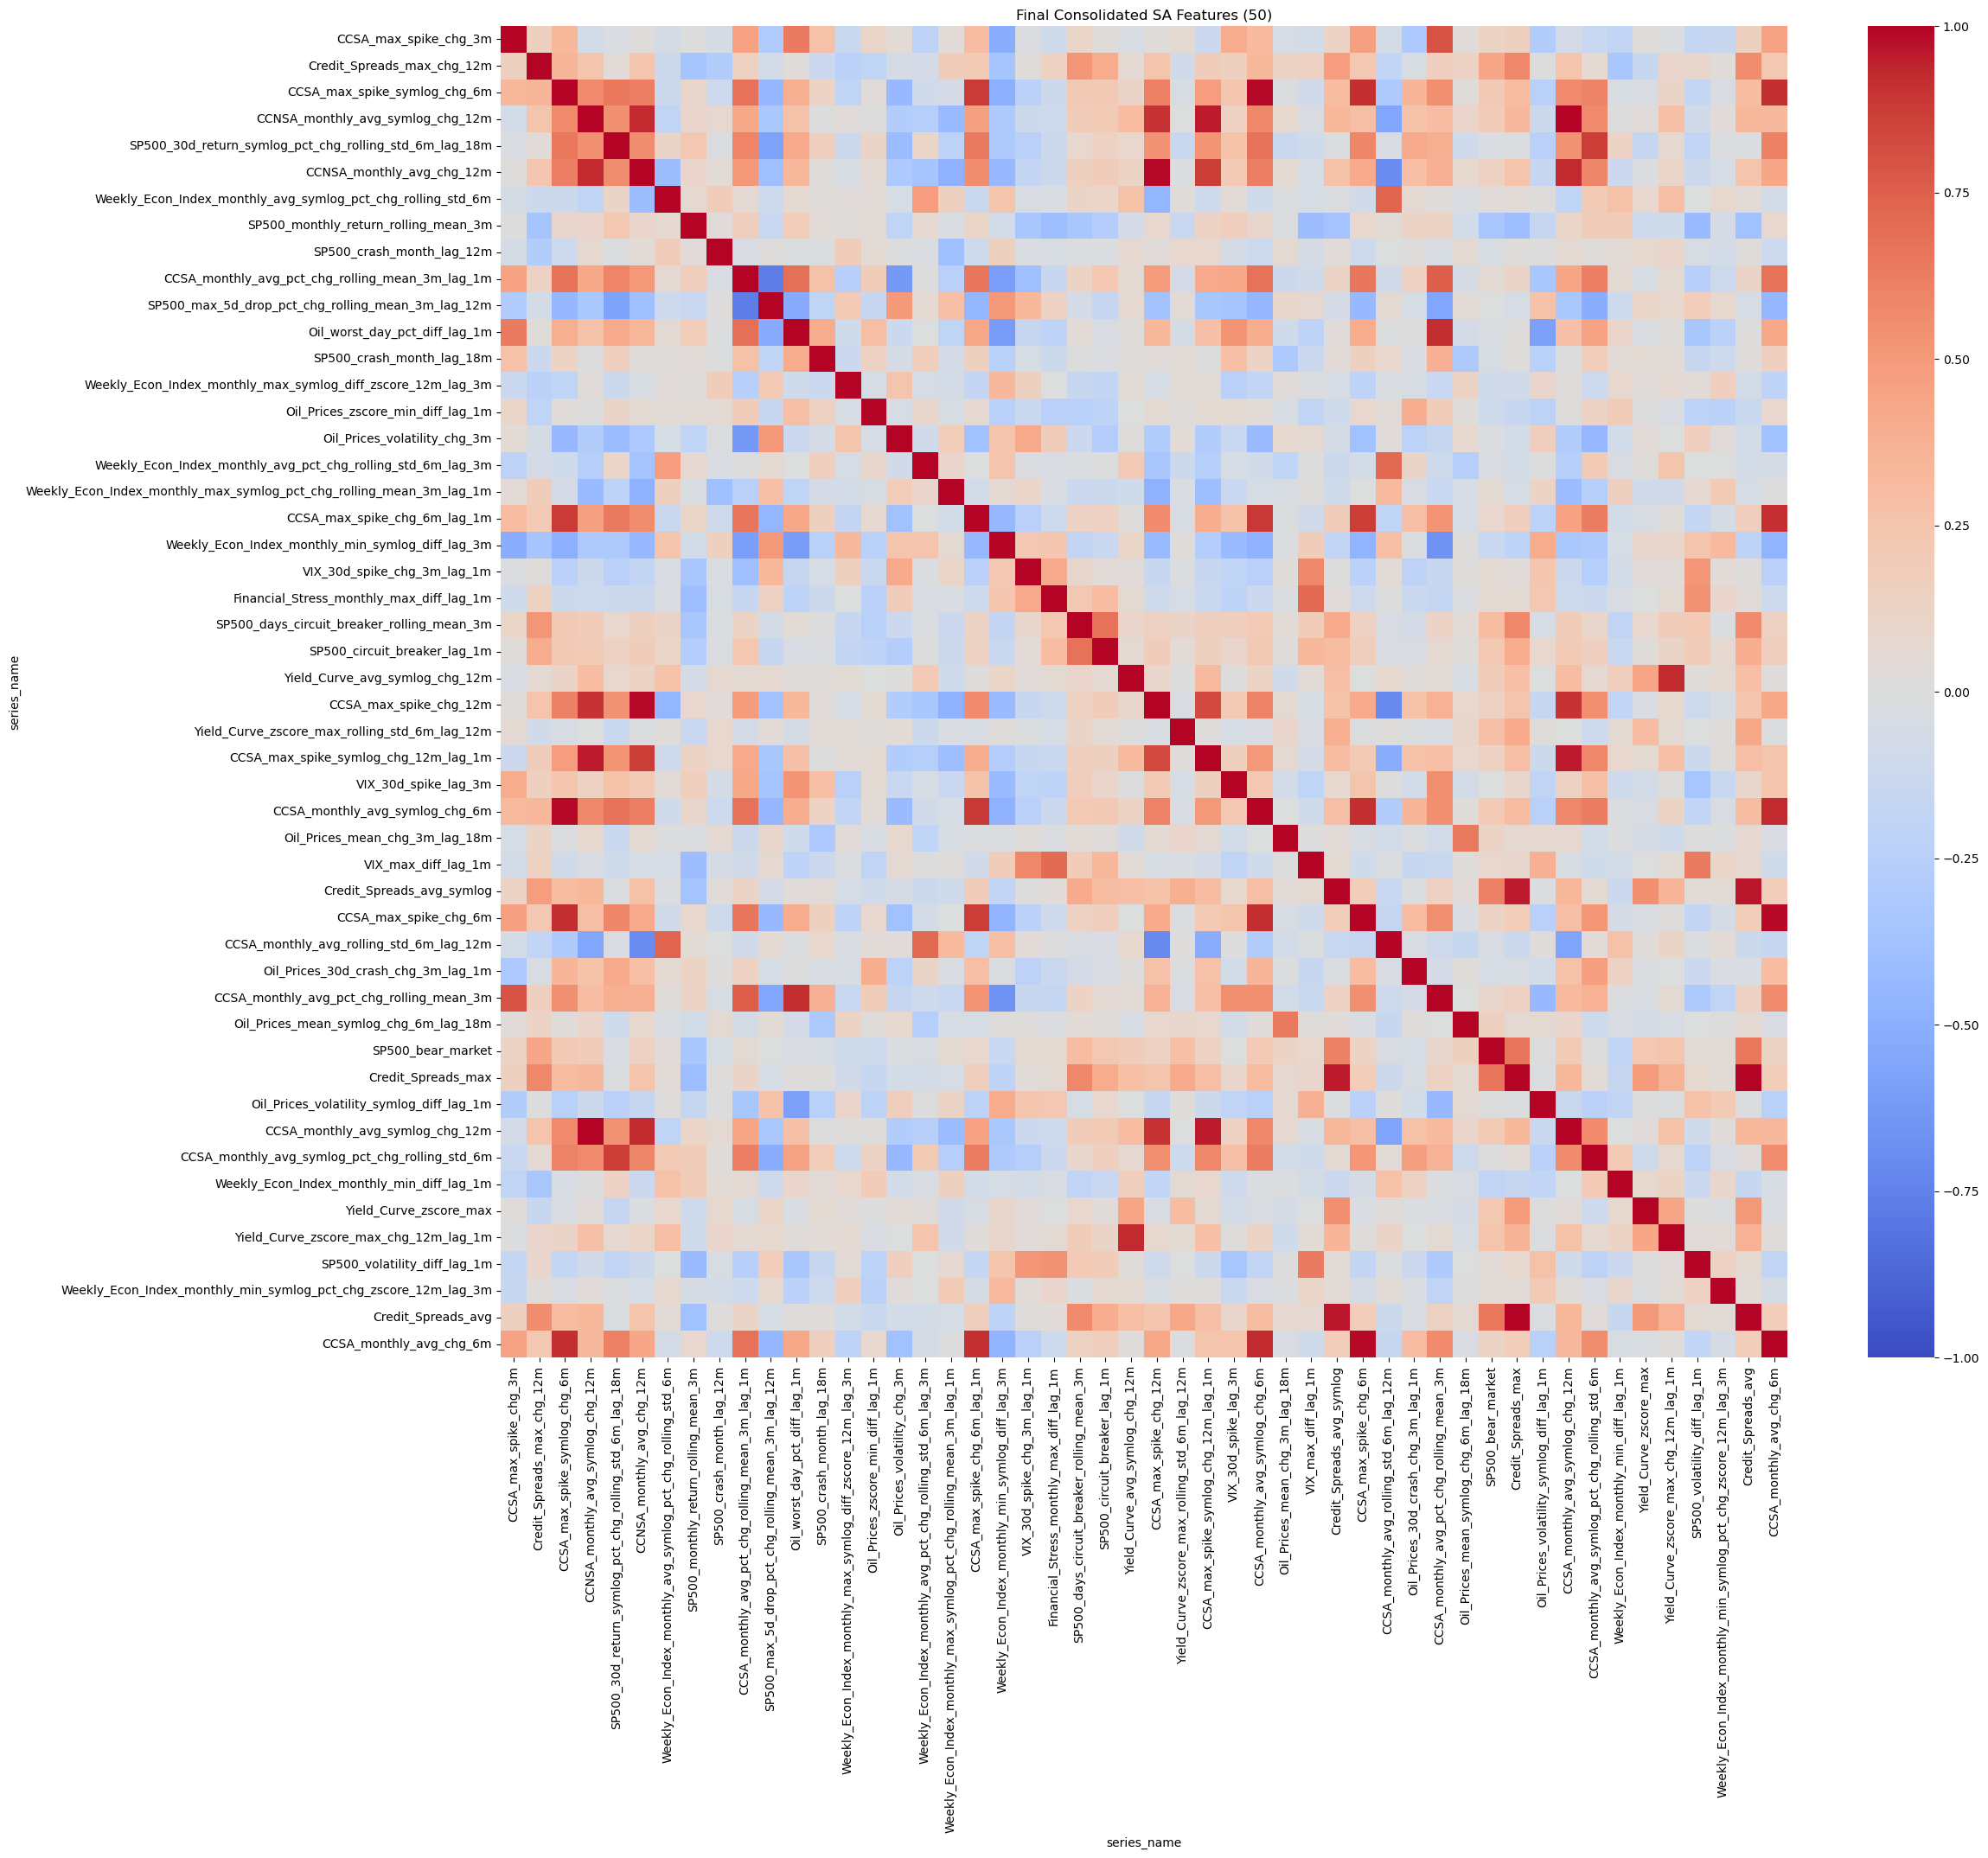

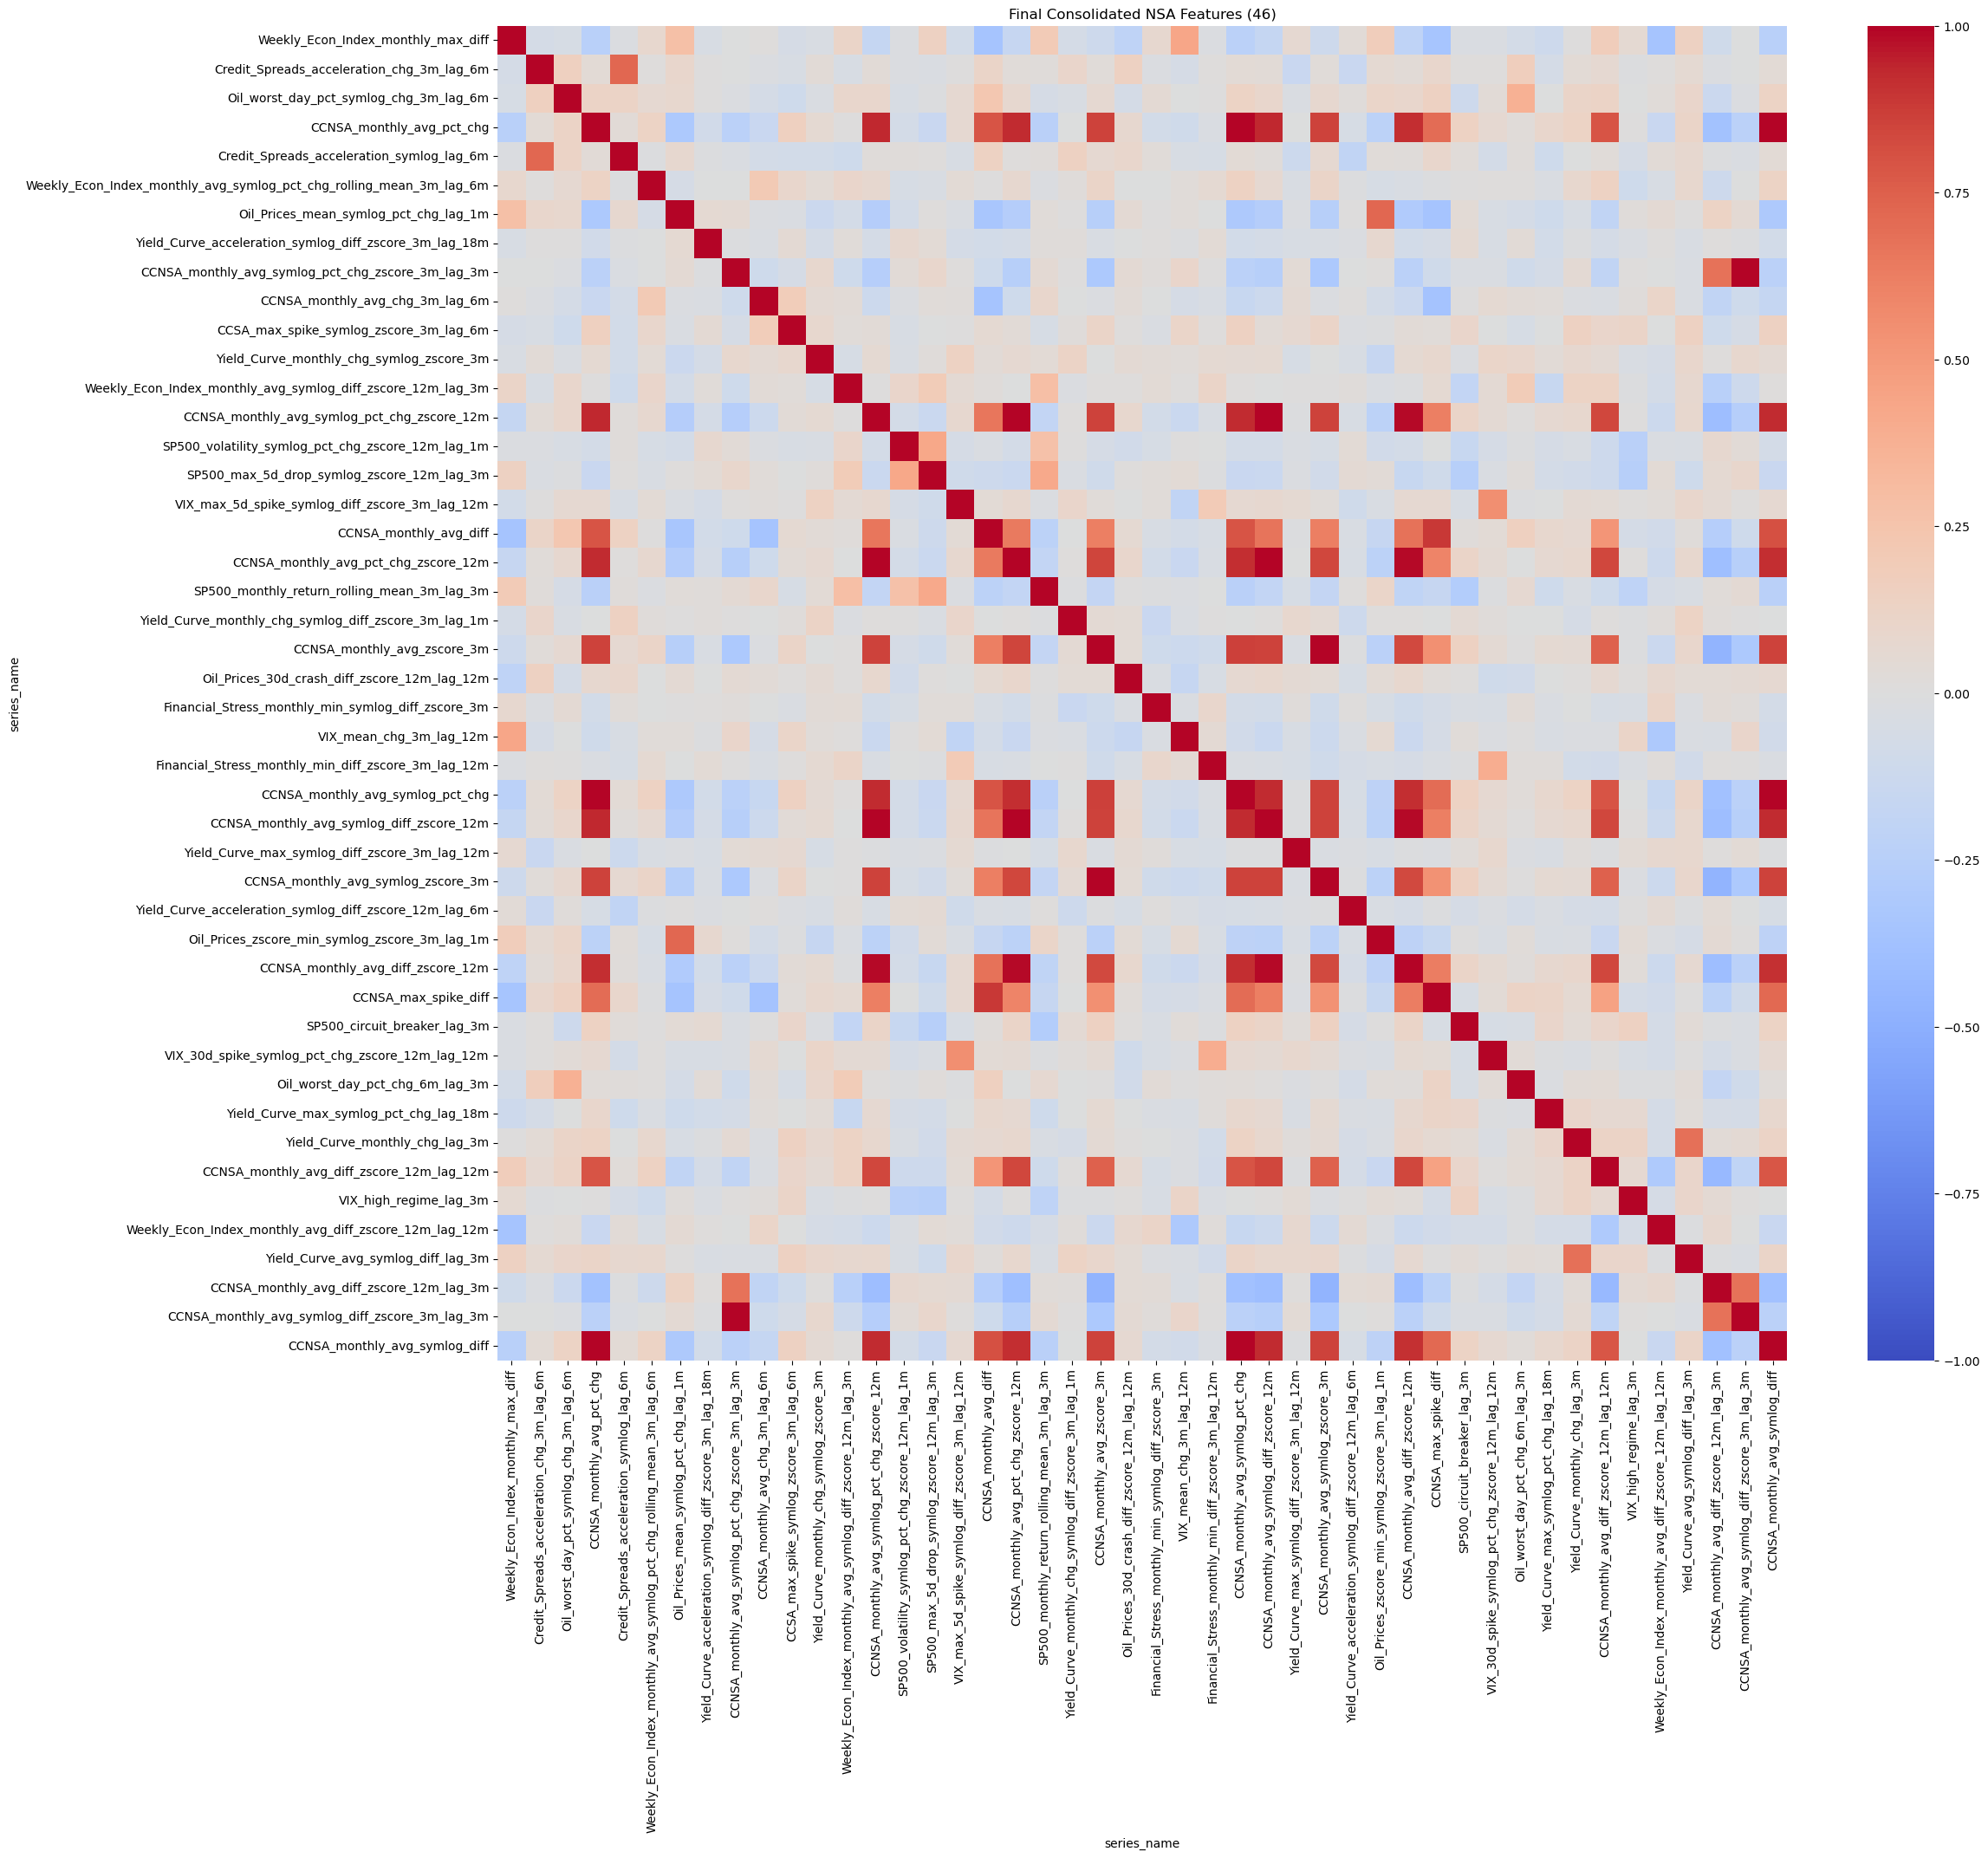

In [116]:
# --- 17. Final Consolidated Matrix ---
# Visualizing the merged feature sets.

# SA Plot
if final_sa_candidates:
    plt.figure(figsize=(24, 20))
    sns.heatmap(df_pivot[final_sa_candidates].corr(), cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title(f"Final Consolidated SA Features ({len(final_sa_candidates)})")
    plt.show()

# NSA Plot
if final_nsa_candidates:
    plt.figure(figsize=(24, 20))
    sns.heatmap(df_pivot[final_nsa_candidates].corr(), cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title(f"Final Consolidated NSA Features ({len(final_nsa_candidates)})")
    plt.show()

